# 📈 Tesla (TSLA) Advanced Forecasting Lab

**Goal:** forecast TSLA closing prices for the next **1–2 trading weeks** with a modern, rigorously validated toolkit — and measure honestly how good the forecasts really are.

| Stage | What happens | Where |
|---|---|---|
| 1 | Data ingestion, validation & quality checks (live → cache → offline fallback) | §1 |
| 2 | Exploratory analysis: distributions, volatility clustering, stationarity, seasonality, drawdowns | §2 |
| 3 | 56 causal features (momentum, volatility regimes, trend, volume, calendar, SPY/QQQ/VIX context) | §3 |
| 4 | Why *price-level R²* (used in the first version) is misleading | §4 |
| 5 | **Walk-forward backtest** of 10 models: random walk, drift, ARIMA, Theta, Ridge, LightGBM, XGBoost, GRU-attention, TCN, Transformer | §5 |
| 6 | Leak-free **online ensemble** | §6 |
| 7 | **Conformal prediction intervals** (calibrated uncertainty) | §7 |
| 8 | Residual diagnostics | §8 |
| 9 | Interpretability: SHAP, feature importance, training curves | §9 |
| 10 | Final forecast, Monte-Carlo risk view, volatility outlook | §10–12 |
| 11 | News sentiment & insights, save artifacts, conclusions | §13–15 |

> **Reading guide.** All models predict *cumulative log-returns* `log(P[t+h]/P[t])` for h = 1…10 trading days and are scored on **identical out-of-sample origins** against the **random-walk benchmark**. Every number below is regenerated from live data when you run the notebook.

> ⚠️ Educational research, **not financial advice**.

## 0 · Setup

In [1]:
import os, sys, platform, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").exists()), Path.cwd().resolve())
os.chdir(ROOT)
try:
    import tesla_forecast
except ImportError:                      # running without `pip install -e .`
    sys.path.insert(0, str(ROOT / "src"))
    import tesla_forecast

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.io as pio
import torch
from IPython.display import display, Markdown

from tesla_forecast import load_config
from tesla_forecast.forecasting import ForecastPipeline
from tesla_forecast.viz import plots, apply_matplotlib_style, PALETTE
from tesla_forecast.utils import set_seed

pio.renderers.default = "plotly_mimetype+notebook_connected"
apply_matplotlib_style()
pd.set_option("display.width", 180, "display.max_columns", 40, "display.float_format", "{:,.4f}".format)

cfg = load_config()
set_seed(cfg.seed)
FIG = ROOT / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
def shw(name):
    # save the current matplotlib figure to reports/figures/<name>.png, then display it
    plt.savefig(FIG / f"{name}.png", bbox_inches="tight", dpi=130)
    plt.show()
BLUE, ORANGE, AQUA, VIOLET, GREY = PALETTE["blue"], PALETTE["orange"], PALETTE["aqua"], PALETTE["violet"], "#8a8a85"
DIVERGING = sns.blend_palette([ORANGE, "#f0efec", BLUE], as_cmap=True)

env = pd.Series({
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "torch": torch.__version__, "device": "cuda: " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "tesla_forecast": tesla_forecast.__version__, "horizon (trading days)": cfg.horizon,
    "models": ", ".join(cfg.models.enabled)}, name="environment")
env.to_frame()

,environment
python,3.12.13
numpy,2.4.1
pandas,3.0.3
torch,2.14.0+cu130
device,cuda: NVIDIA RTX A2000 Laptop GPU
tesla_forecast,2.0.0
horizon (trading days),10
models,"naive, drift, arima, theta, ridge, lightgbm, x..."


## 1 · Data ingestion & quality

`ForecastPipeline.prepare()` follows a resilient chain: **live Yahoo Finance → on-disk cache → stale cache → bundled legacy CSV** (the 2015–Feb 2025 file from the original project), so the notebook never fails offline. It also drops any *incomplete intraday bar* so the last observation is always a final close.

In [2]:
pipe = ForecastPipeline(cfg).prepare()
prices = pipe.prices.df
close = prices["Close"]
ret = np.log(close).diff().dropna()

print(f"source       : {pipe.prices.source}   (live={pipe.prices.is_live})")
print(f"history      : {prices.index[0].date()} → {prices.index[-1].date()}   ({len(prices):,} trading days)")
print(f"features     : {len(pipe.ff.feature_cols)}   market-context features: {pipe.ff.has_context}")
print(f"model frame  : {len(pipe.ff.frame):,} rows after {cfg.features.warmup}-day warm-up")
for n in pipe.prices.notes: print("note         :", n)
display(prices.tail(8).style.format({"Open": "${:,.2f}", "High": "${:,.2f}", "Low": "${:,.2f}", "Close": "${:,.2f}", "Volume": "{:,.0f}"}))

02:34:36 | INFO    | tesla_forecast.forecasting.pipeline | data source=cache rows=2705 features=56 context=True last=2026-10-06


source       : cache   (live=True)
history      : 2015-01-02 → 2026-10-06   (2,957 trading days)
features     : 56   market-context features: True
model frame  : 2,705 rows after 252-day warm-up


,Open,High,Low,Close,Volume
Date,,,,,
2026-09-25 00:00:00,$384.62,$386.83,$367.67,$372.11,"45,999,500"
2026-09-28 00:00:00,$368.06,$369.43,$356.80,$357.45,"39,452,900"
2026-09-29 00:00:00,$358.40,$358.74,$351.67,$352.84,"32,492,400"
2026-09-30 00:00:00,$352.11,$355.22,$345.88,$354.81,"39,235,800"
2026-10-01 00:00:00,$356.81,$359.79,$353.80,$354.11,"31,080,800"
2026-10-02 00:00:00,$360.08,$374.60,$359.41,$370.59,"55,330,100"
2026-10-05 00:00:00,$369.00,$381.59,$364.91,$378.73,"42,232,700"
2026-10-06 00:00:00,$381.98,$383.33,$378.52,$380.68,"27,372,057"


In [3]:
from tesla_forecast.data.calendar import is_trading_day
from tesla_forecast.data.loader import parse_legacy_csv

# 1) Calendar completeness against the NYSE trading calendar
expected = pd.DatetimeIndex([d for d in pd.bdate_range(prices.index[0], prices.index[-1]) if is_trading_day(d)])
missing, extra = expected.difference(prices.index), prices.index.difference(expected)

# 2) Cross-check the live series against the bundled legacy CSV on overlapping dates
legacy = parse_legacy_csv(cfg.resolve(cfg.data.local_csv))
ov = legacy[["Close"]].join(prices[["Close"]], how="inner", lsuffix="_legacy", rsuffix="_now")
rel = (ov.Close_legacy / ov.Close_now - 1).abs()

quality = pd.DataFrame({
    "check": ["expected trading days", "rows present", "missing trading days", "rows on non-trading days",
              "duplicate dates", "non-positive prices", "High < Low rows", "overlap with legacy CSV (days)",
              "median |legacy/live - 1|", "max |legacy/live - 1|"],
    "value": [len(expected), len(prices), len(missing), len(extra), int(prices.index.duplicated().sum()),
              int((prices[["Open","High","Low","Close"]] <= 0).sum().sum()), int((prices.High < prices.Low).sum()),
              len(ov), f"{rel.median():.5%}", f"{rel.max():.3%}"]})
display(quality.set_index("check"))
if len(missing): print("first missing dates:", [d.date().isoformat() for d in missing[:8]])

,value
check,
expected trading days,2957
rows present,2957
missing trading days,0
rows on non-trading days,0
duplicate dates,0
non-positive prices,0
High < Low rows,0
overlap with legacy CSV (days),2515
median |legacy/live - 1|,0.00001%


## 2 · Exploratory analysis

### 2.1 Price history, volume and drawdowns

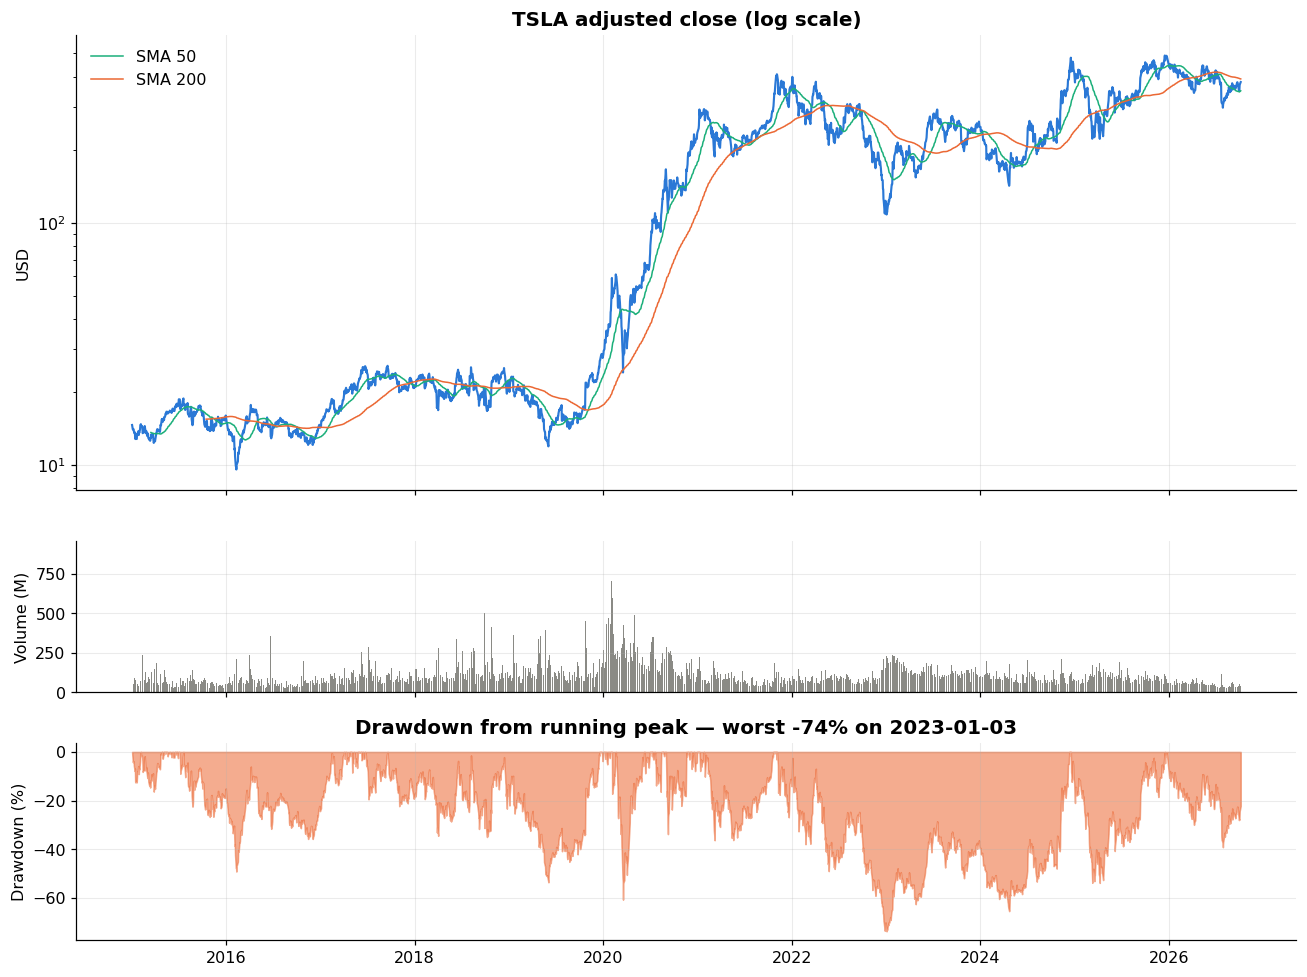

In [4]:
fig, ax = plt.subplots(3, 1, figsize=(12, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1.3]})
ax[0].semilogy(close.index, close, color=BLUE, lw=1.4)
ax[0].set_title("TSLA adjusted close (log scale)"); ax[0].set_ylabel("USD")
for w, c in ((50, AQUA), (200, ORANGE)):
    ax[0].semilogy(close.index, close.rolling(w).mean(), color=c, lw=1, label=f"SMA {w}")
ax[0].legend(loc="upper left")
ax[1].bar(prices.index, prices.Volume / 1e6, color=GREY, width=1.5); ax[1].set_ylabel("Volume (M)")
dd = close / close.cummax() - 1
ax[2].fill_between(dd.index, dd * 100, 0, color=ORANGE, alpha=.55); ax[2].set_ylabel("Drawdown (%)")
ax[2].set_title(f"Drawdown from running peak — worst {dd.min():.0%} on {dd.idxmin().date()}")
plt.tight_layout(); shw("01_price_volume_drawdown")

In [5]:
plots.price_chart(prices, last_n=250).show()

### 2.2 Return distribution — fat tails, skew, and why Gaussian intervals fail

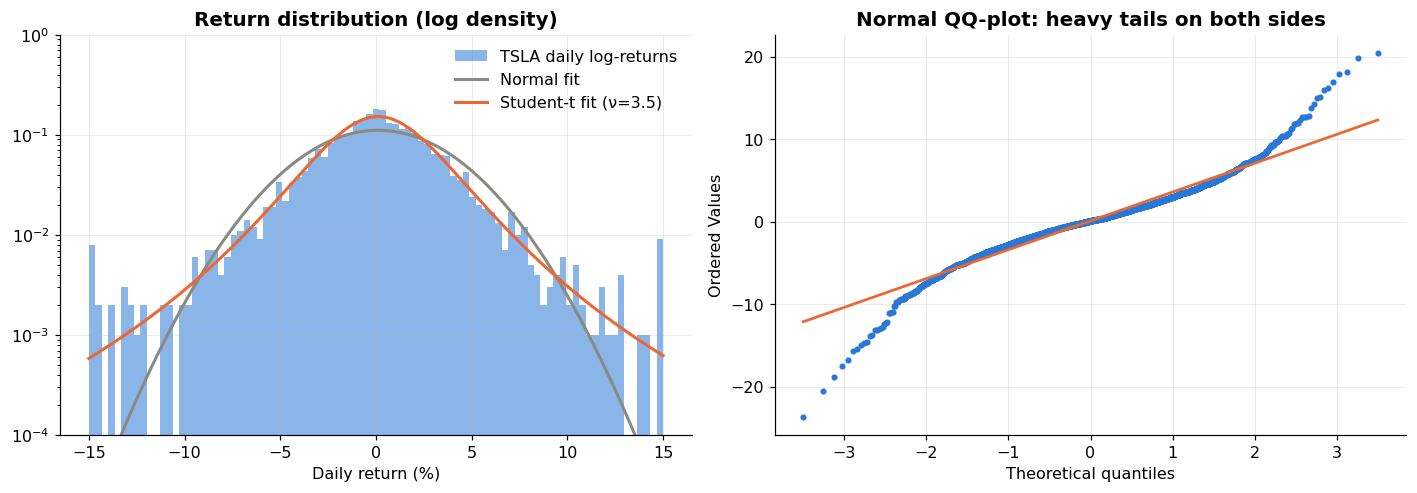

,value
mean %/day,0.1103
std %/day,3.5851
annualised vol %,56.9119
skew,-0.0721
excess kurtosis,4.4013
min %,-23.6518
max %,20.4491
Jarque-Bera p-value,0.0000
P(|ret| > 3σ) actual %,1.5562
P(|ret| > 3σ) if Normal %,0.2700


In [6]:
from scipy import stats
r = ret * 100
mu, sd = r.mean(), r.std()
df_t, loc_t, scale_t = stats.t.fit(r)
jb = stats.jarque_bera(r)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
bins = np.linspace(-15, 15, 90)
ax[0].hist(r.clip(-15, 15), bins=bins, density=True, color=BLUE, alpha=.55, label="TSLA daily log-returns")
xs = np.linspace(-15, 15, 600)
ax[0].plot(xs, stats.norm.pdf(xs, mu, sd), color=GREY, lw=2, label="Normal fit")
ax[0].plot(xs, stats.t.pdf(xs, df_t, loc_t, scale_t), color=ORANGE, lw=2, label=f"Student-t fit (ν={df_t:.1f})")
ax[0].set_yscale("log"); ax[0].set_ylim(1e-4, 1); ax[0].set_xlabel("Daily return (%)"); ax[0].legend()
ax[0].set_title("Return distribution (log density)")
stats.probplot(r, dist="norm", plot=ax[1])
ax[1].get_lines()[0].set(color=BLUE, markersize=3); ax[1].get_lines()[1].set(color=ORANGE)
ax[1].set_title("Normal QQ-plot: heavy tails on both sides")
plt.tight_layout(); shw("02_return_distribution")

summary = pd.Series({"mean %/day": mu, "std %/day": sd, "annualised vol %": sd * np.sqrt(252), "skew": stats.skew(r),
                     "excess kurtosis": stats.kurtosis(r), "min %": r.min(), "max %": r.max(),
                     "Jarque-Bera p-value": jb.pvalue, "P(|ret| > 3σ) actual %": (np.abs(r - mu) > 3 * sd).mean() * 100,
                     "P(|ret| > 3σ) if Normal %": 0.27}, name="value")
display(summary.to_frame())

### 2.3 Volatility clustering — returns are unpredictable, *risk* is predictable

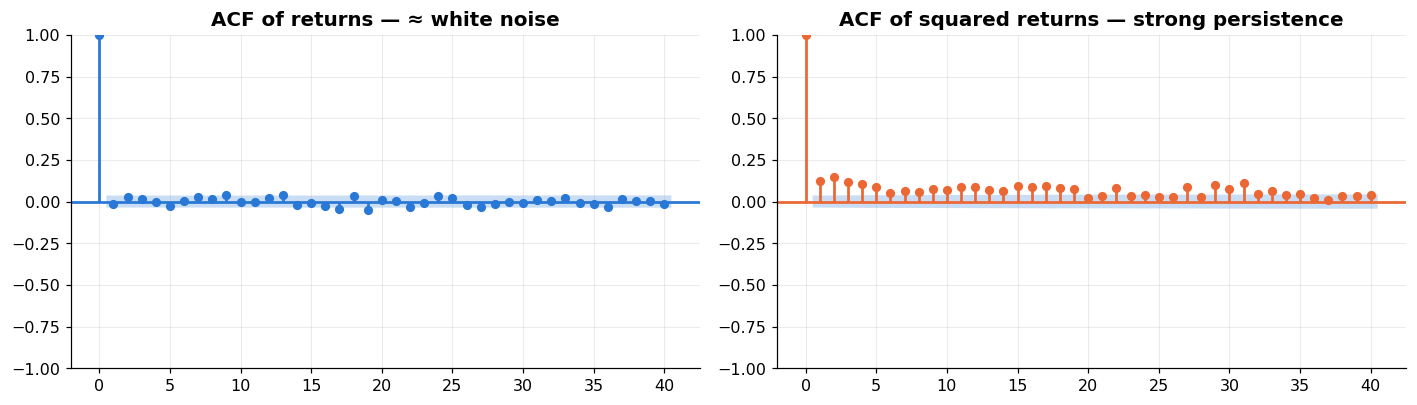

,returns,squared returns
Ljung-Box lag,,
5,3.56e-01,6.87e-42
10,2.57e-01,8.33e-51
20,6.84e-03,1.16e-82


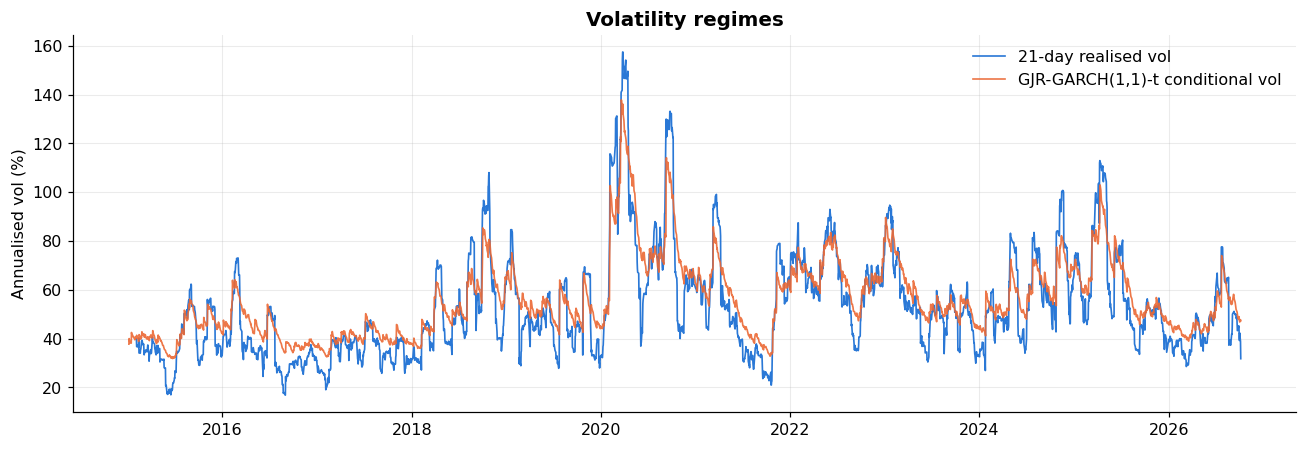

In [7]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from tesla_forecast.models.volatility import garch_conditional_vol

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
plot_acf(ret, lags=40, ax=ax[0], color=BLUE, vlines_kwargs={"colors": BLUE}); ax[0].set_title("ACF of returns — ≈ white noise")
plot_acf(ret ** 2, lags=40, ax=ax[1], color=ORANGE, vlines_kwargs={"colors": ORANGE}); ax[1].set_title("ACF of squared returns — strong persistence")
plt.tight_layout(); shw("03_acf_returns")

lb = pd.DataFrame({"returns": acorr_ljungbox(ret, lags=[5, 10, 20])["lb_pvalue"],
                   "squared returns": acorr_ljungbox(ret ** 2, lags=[5, 10, 20])["lb_pvalue"]})
lb.index.name = "Ljung-Box lag"; display(lb.style.format("{:.2e}").set_caption("p-values (small ⇒ serial dependence)"))

cond = garch_conditional_vol(ret)
rv = ret.rolling(21).std() * np.sqrt(252)
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(rv.index, rv * 100, color=BLUE, lw=1.1, label="21-day realised vol")
if cond is not None: ax.plot(cond.index, cond * 100, color=ORANGE, lw=1.1, alpha=.9, label="GJR-GARCH(1,1)-t conditional vol")
ax.set_ylabel("Annualised vol (%)"); ax.set_title("Volatility regimes"); ax.legend(); plt.tight_layout(); shw("04_volatility_regimes")

### 2.4 Stationarity — why we model returns, not prices

In [8]:
from statsmodels.tsa.stattools import adfuller, kpss
rows = []
for name, s in {"price": close, "log price": np.log(close), "log return": ret}.items():
    adf_p = adfuller(s.dropna(), autolag="AIC")[1]
    kp_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
    rows.append({"series": name, "ADF p-value (H0: unit root)": adf_p, "KPSS p-value (H0: stationary)": kp_p,
                 "verdict": "stationary" if (adf_p < .05 and kp_p > .05) else "non-stationary" if (adf_p >= .05 and kp_p <= .05) else "ambiguous"})
display(pd.DataFrame(rows).set_index("series").style.format({"ADF p-value (H0: unit root)": "{:.4f}", "KPSS p-value (H0: stationary)": "{:.4f}"}))

/tmp/ipykernel_325567/1568460899.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kp_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_325567/1568460899.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kp_p = kpss(s.dropna(), regression="c", nlags="auto")[1]
/tmp/ipykernel_325567/1568460899.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kp_p = kpss(s.dropna(), regression="c", nlags="auto")[1]


,ADF p-value (H0: unit root),KPSS p-value (H0: stationary),verdict
series,,,
price,0.6654,0.0100,non-stationary
log price,0.8122,0.0100,non-stationary
log return,0.0000,0.1000,stationary


### 2.5 Trend / seasonality (STL) and calendar effects

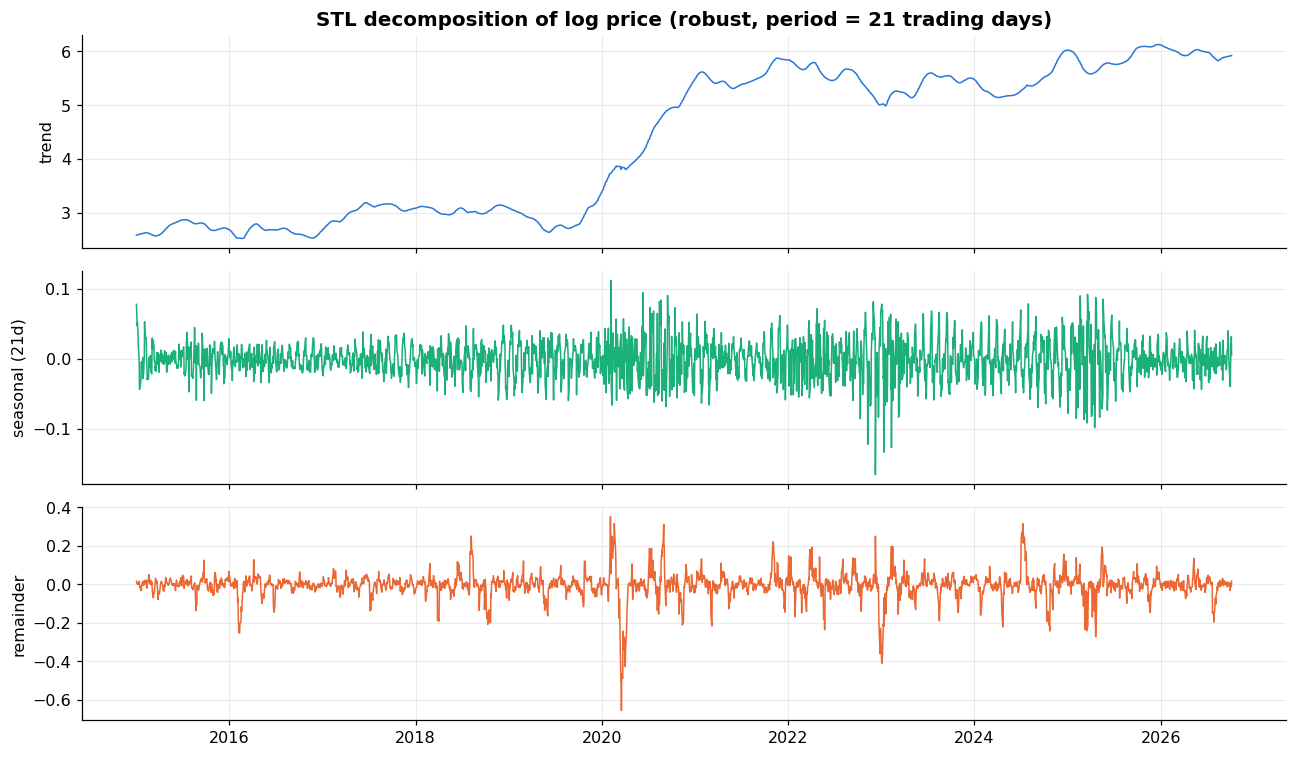

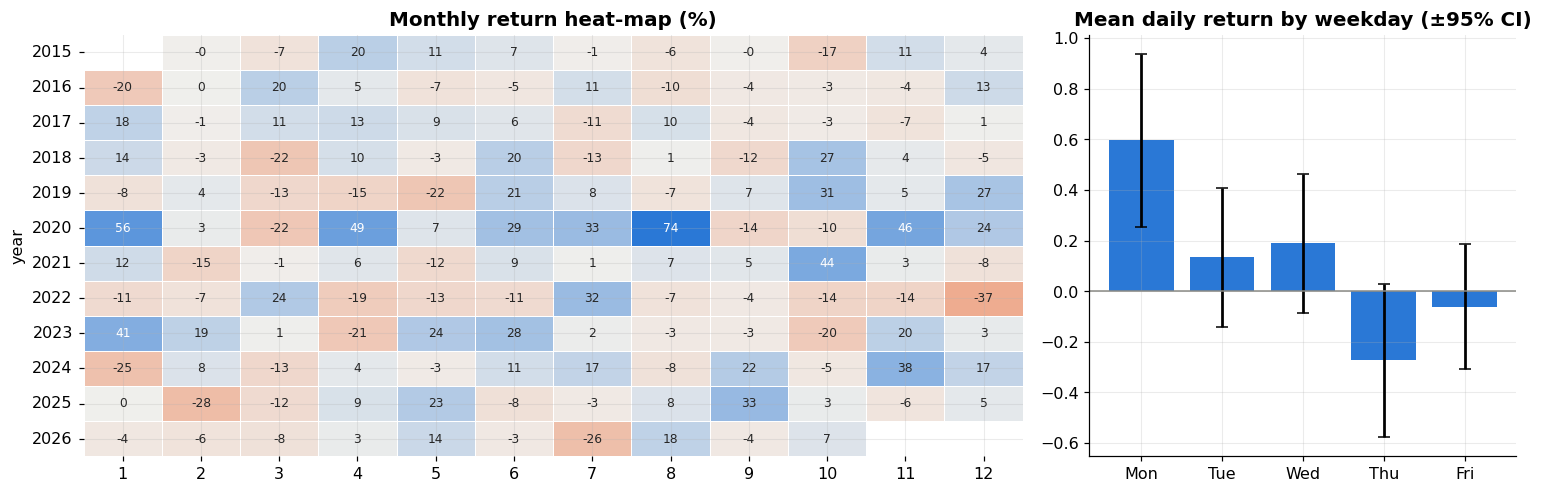

In [9]:
from statsmodels.tsa.seasonal import STL
stl = STL(np.log(close).reset_index(drop=True), period=21, robust=True).fit()
comp = pd.DataFrame({"trend": stl.trend.values, "seasonal (21d)": stl.seasonal.values, "remainder": stl.resid.values}, index=close.index)
fig, ax = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for a, (c, col) in zip(ax, zip(comp.columns, (BLUE, AQUA, ORANGE))):
    a.plot(comp.index, comp[c], color=col, lw=1); a.set_ylabel(c)
ax[0].set_title("STL decomposition of log price (robust, period = 21 trading days)")
plt.tight_layout(); shw("05_stl_decomposition")

monthly = close.resample("ME").last().pct_change().dropna()
heat = monthly.to_frame("r").assign(year=lambda d: d.index.year, month=lambda d: d.index.month).pivot(index="year", columns="month", values="r") * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6), gridspec_kw={"width_ratios": [2.2, 1]})
sns.heatmap(heat, annot=True, fmt=".0f", cmap=DIVERGING, center=0, cbar=False, ax=ax[0], linewidths=.5, annot_kws={"size": 8})
ax[0].set_title("Monthly return heat-map (%)"); ax[0].set_xlabel("")
dow = (ret * 100).groupby(ret.index.dayofweek).agg(["mean", "sem"])
ax[1].bar(["Mon", "Tue", "Wed", "Thu", "Fri"], dow["mean"], yerr=1.96 * dow["sem"], color=BLUE, capsize=4)
ax[1].axhline(0, color=GREY, lw=1); ax[1].set_title("Mean daily return by weekday (±95% CI)")
plt.tight_layout(); shw("06_monthly_returns_weekday")

### 2.6 Market context: SPY, QQQ and VIX
TSLA is a high-beta stock; the broad market and the VIX are the only *exogenous* information the models receive (all strictly lagged-safe — value at *t* uses data ≤ *t*).

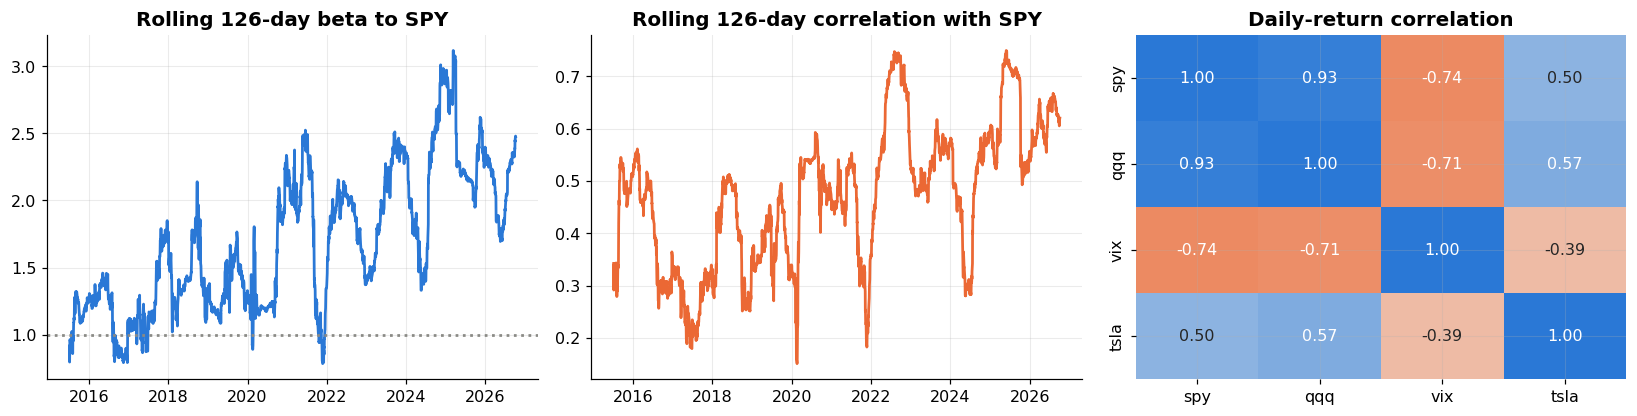

In [10]:
from tesla_forecast.data.loader import load_market_context
ctx = load_market_context(cfg, prices.index)
if ctx is None:
    print("Market-context data unavailable (offline) — skipping this section; models fall back to TSLA-only features.")
else:
    lr = np.log(ctx).diff().join(ret.rename("tsla")).dropna()
    beta = lr["tsla"].rolling(126).cov(lr["spy"]) / lr["spy"].rolling(126).var()
    corr = lr["tsla"].rolling(126).corr(lr["spy"])
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.9))
    ax[0].plot(beta.index, beta, color=BLUE); ax[0].axhline(1, color=GREY, ls=":"); ax[0].set_title("Rolling 126-day beta to SPY")
    ax[1].plot(corr.index, corr, color=ORANGE); ax[1].set_title("Rolling 126-day correlation with SPY")
    sns.heatmap(lr.corr(), annot=True, fmt=".2f", cmap=DIVERGING, center=0, cbar=False, ax=ax[2]); ax[2].set_title("Daily-return correlation")
    plt.tight_layout(); shw("07_market_context")

## 3 · Feature engineering (56 causal features)

Families: **momentum** (multi-horizon returns), **volatility regimes** (rolling, EWMA, Parkinson, Garman-Klass, ATR, skew/kurtosis), **trend & mean-reversion** (distance to SMAs, RSI, MACD, Bollinger, stochastic, 52-week range), **volume/liquidity**, **calendar**, and **market context**. All are *scale-free and stationary*; the price level itself is never a feature. A unit test proves causality: altering the future leaves past feature rows unchanged.

,trend / mean-reversion,momentum,volatility,market context,volume,calendar
n features,15,13,13,9,4,2


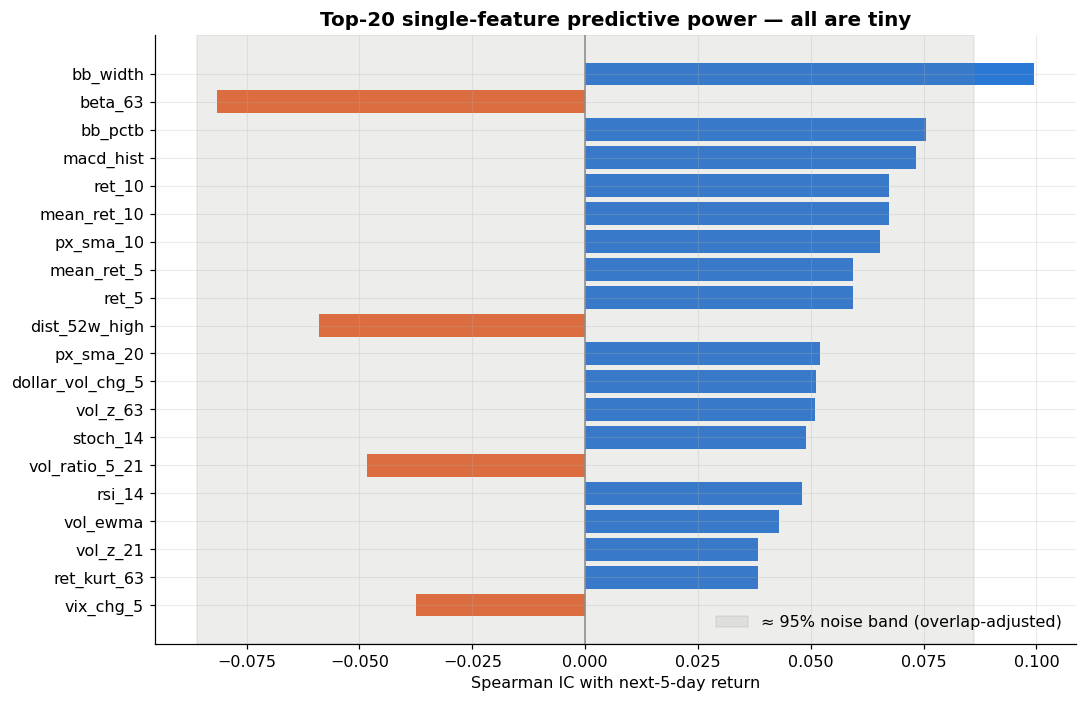

features outside the noise band: 1 of 56  (expected by chance ≈ 3)


In [11]:
from tesla_forecast.features.engineering import forward_log_returns
ff = pipe.ff; frame = ff.frame; fcols = ff.feature_cols
groups = {"momentum": ("ret_", "mean_ret", "gap", "intraday", "range_hl"), "volatility": ("vol_", "atr", "ret_skew", "ret_kurt", "ret_abs"),
          "trend / mean-reversion": ("px_sma", "sma_", "rsi", "stoch", "macd", "bb_", "dist_", "drawdown"),
          "volume": ("vol_z", "dollar", "obv"), "calendar": ("dow", "month"), "market context": ("spy", "qqq", "vix", "beta", "rel_")}
def family(c):
    for g in ("volume", "calendar", "market context", "volatility", "trend / mean-reversion", "momentum"):
        if c.startswith(groups[g]): return g
    return "other"
fam = pd.Series({c: family(c) for c in fcols})
display(fam.value_counts().rename("n features").to_frame().T)

# Information coefficient (Spearman) of each feature with the *next-5-day* return
y5 = pd.Series(forward_log_returns(frame["close"].to_numpy(), 5)[:, 4], index=frame.index)
ic = pd.DataFrame({c: stats.spearmanr(frame[c][y5.notna()], y5.dropna()) for c in fcols}, index=["ic", "p"]).T
n_eff = y5.notna().sum() / 5            # overlapping 5-day windows -> divide the sample size by the horizon
ic["t_eff"] = ic["ic"] * np.sqrt((n_eff - 2) / (1 - ic["ic"] ** 2))
top = ic.reindex(ic.ic.abs().sort_values(ascending=False).index).head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5))
ax.barh(top.index, top.ic, color=[BLUE if v > 0 else ORANGE for v in top.ic])
ax.axvline(0, color=GREY, lw=1); ax.set_xlabel("Spearman IC with next-5-day return")
crit = 2.0 / np.sqrt(n_eff); ax.axvspan(-crit, crit, color=GREY, alpha=.15, label="≈ 95% noise band (overlap-adjusted)")
ax.set_title("Top-20 single-feature predictive power — all are tiny"); ax.legend(loc="lower right")
plt.tight_layout(); shw("08_feature_information_coefficient")
print(f"features outside the noise band: {(ic.ic.abs() > crit).sum()} of {len(ic)}  (expected by chance ≈ {0.05 * len(ic):.0f})")

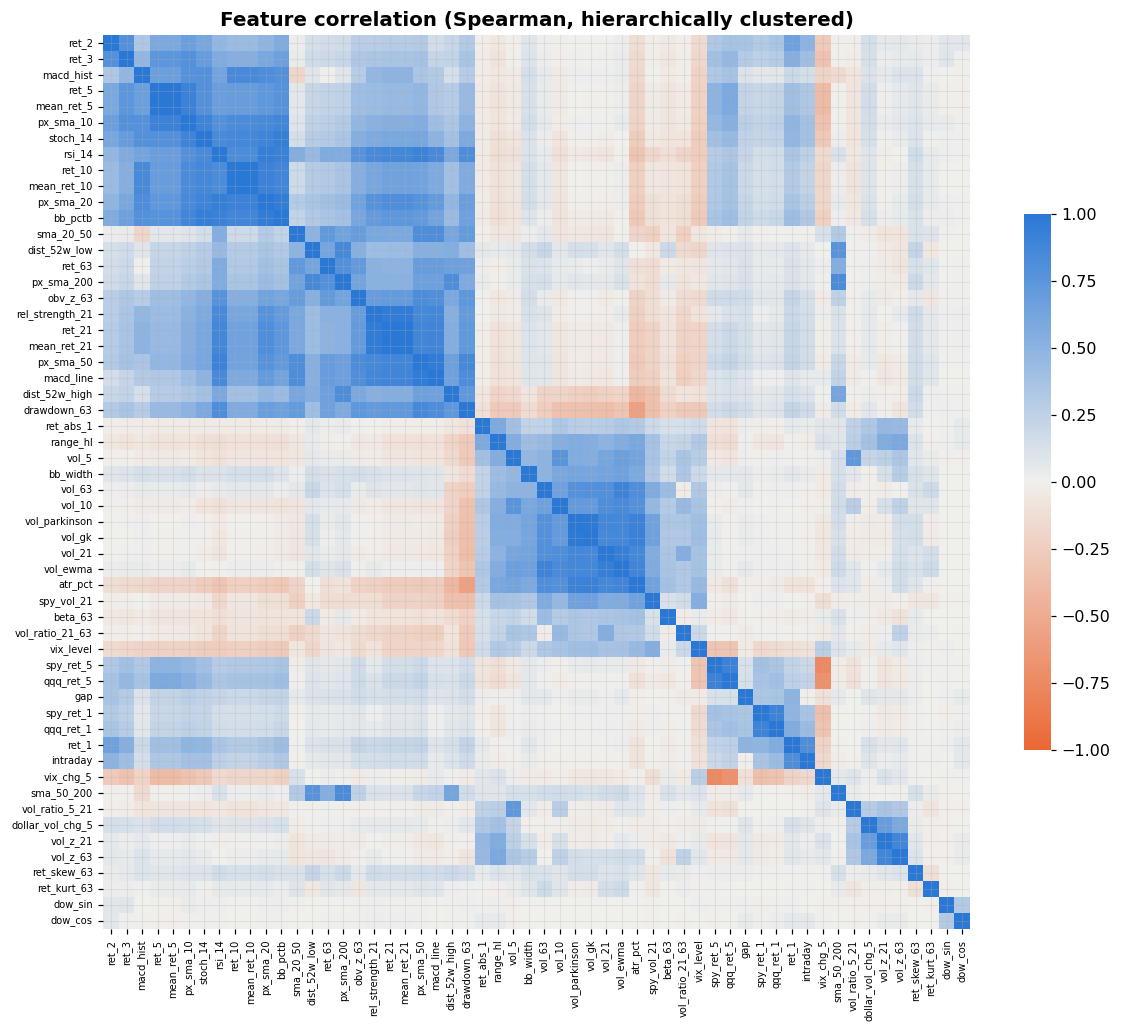

In [12]:
corr = frame[fcols].corr(method="spearman")
order = sns.clustermap(corr, method="average", cmap=DIVERGING, center=0, figsize=(1, 1)).dendrogram_row.reordered_ind
plt.close("all")
fig, ax = plt.subplots(figsize=(11, 9.5))
sns.heatmap(corr.iloc[order, order], cmap=DIVERGING, center=0, vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True, cbar_kws={"shrink": .6})
ax.tick_params(labelsize=6.5); ax.set_title("Feature correlation (Spearman, hierarchically clustered)")
plt.tight_layout(); shw("09_feature_correlation")

## 4 · Why price-level R² is misleading

The original notebook reported R² on **price levels**. Because prices are extremely autocorrelated, *even the dumbest forecast* ("tomorrow = today") scores R² ≈ 0.99 on prices. Scoring **returns**, or better, comparing against that dumb forecast, is the honest test.

,value
R² of naive forecast on PRICE levels,0.9854
R² of naive forecast on daily RETURNS,-0.0011
MAPE of naive 1-day forecast (%),2.6365


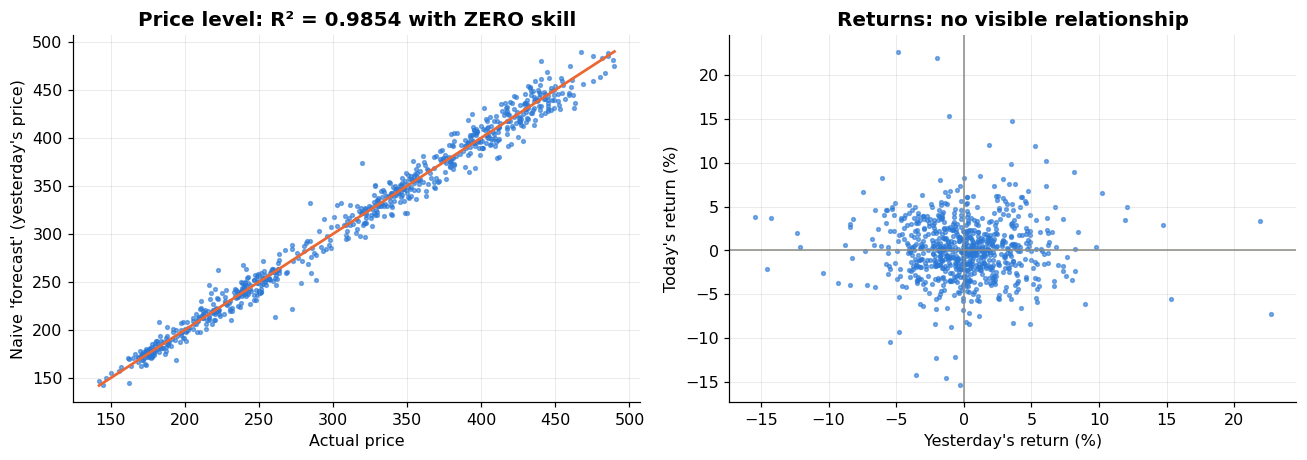

In [13]:
from sklearn.metrics import r2_score, mean_absolute_percentage_error
test = close.iloc[-756:]
nv = test.shift(1).dropna(); act = test.loc[nv.index]
tbl = pd.Series({
    "R² of naive forecast on PRICE levels": r2_score(act, nv),
    "R² of naive forecast on daily RETURNS": r2_score(act.pct_change().dropna(), np.zeros(len(act) - 1)),
    "MAPE of naive 1-day forecast (%)": mean_absolute_percentage_error(act, nv) * 100}, name="value")
display(tbl.to_frame())
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].scatter(act, nv, s=6, color=BLUE, alpha=.6); ax[0].plot([act.min(), act.max()], [act.min(), act.max()], color=ORANGE)
ax[0].set_xlabel("Actual price"); ax[0].set_ylabel("Naive 'forecast' (yesterday's price)"); ax[0].set_title(f"Price level: R² = {tbl.iloc[0]:.4f} with ZERO skill")
rr = act.pct_change().dropna() * 100
ax[1].scatter(rr.shift(1).dropna(), rr.iloc[1:], s=6, color=BLUE, alpha=.6); ax[1].axhline(0, color=GREY, lw=1); ax[1].axvline(0, color=GREY, lw=1)
ax[1].set_xlabel("Yesterday's return (%)"); ax[1].set_ylabel("Today's return (%)"); ax[1].set_title("Returns: no visible relationship")
plt.tight_layout(); shw("10_r2_misleading")

## 5 · Walk-forward backtest of ten models

**Protocol.** Expanding window; the last ~3 years (756 daily forecast origins) are out-of-sample. Every ~quarter (63 trading days) *all* models are re-trained on data available at that time and then forecast from each origin using only information up to that origin. Targets are the cumulative log-returns for h = 1…10.

| Family | Models |
|---|---|
| Baselines | `naive` (random walk), `drift` |
| Statistical | `arima` (AIC-selected ARMA on returns), `theta` |
| Linear ML | `ridge` (purged time-series CV) |
| Boosted trees | `lightgbm`, `xgboost` (direct multi-horizon, volatility-normalised targets) |
| Deep learning (PyTorch) | `gru_attention`, `tcn` (dilated causal), `transformer` — seed-ensembled, Huber loss, early stopping |

In [14]:
import time
t0 = time.time()
bt = pipe.backtest(progress=lambda m: print(m))
print(f"\nbacktest: {len(bt.positions)} origins x {len(bt.preds)} models in {time.time() - t0:.0f}s   |   failures: {sum(bt.failures.values())}")

fold 1/12: train<2023-09-29 (1948 rows), 63 origins


fold 2/12: train<2023-12-29 (2011 rows), 63 origins


fold 3/12: train<2024-04-02 (2074 rows), 63 origins


fold 4/12: train<2024-07-02 (2137 rows), 63 origins


fold 5/12: train<2024-10-01 (2200 rows), 63 origins


...

fold 10/12: train<2026-01-05 (2515 rows), 63 origins


fold 11/12: train<2026-04-07 (2578 rows), 63 origins


fold 12/12: train<2026-07-08 (2641 rows), 63 origins


02:36:42 | INFO    | tesla_forecast.forecasting.pipeline | backtest finished in 117.3s (756 origins, 10 models)



backtest: 756 origins x 10 models in 117s   |   failures: 0


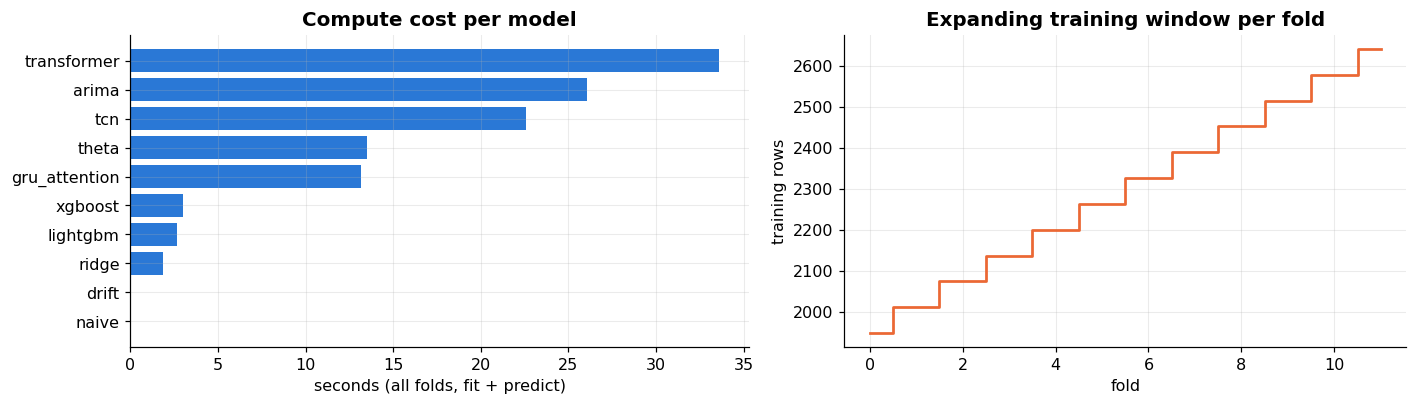

,first origin,last origin,# origins,# refit folds
origins,2023-09-29,2026-10-05,756,12


In [15]:
H = pipe.horizon; M = pipe.metrics; oof = pipe.oof
fit_t = pd.Series(bt.fit_seconds).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.1, 1]})
ax[0].barh(fit_t.index, fit_t.values, color=BLUE); ax[0].set_xlabel("seconds (all folds, fit + predict)"); ax[0].set_title("Compute cost per model")
folds = pd.DataFrame(bt.folds)
ax[1].step(range(len(folds)), folds.n_train, where="mid", color=ORANGE); ax[1].set_title("Expanding training window per fold"); ax[1].set_xlabel("fold"); ax[1].set_ylabel("training rows")
plt.tight_layout(); shw("11_compute_cost")
display(pd.DataFrame({"origins": [bt.dates[0].date(), bt.dates[-1].date(), len(bt.positions), len(folds)]},
                     index=["first origin", "last origin", "# origins", "# refit folds"]).T)

### 5.1 Leaderboards at selected horizons (sorted by RMSE; **Skill** = % RMSE gain over the random walk)

In [16]:
cols = ["model", "RMSE", "MAE", "MAPE_%", "MASE", "DirAcc_%", "OOS_R2_ret_%", "Skill_vs_naive_%", "DM_p"]
for h in (1, 5, 10):
    t = M[M.horizon == h][cols].sort_values("RMSE").set_index("model")
    display(Markdown(f"**Horizon t+{h}** (n = {int(M[(M.horizon == h) & (M.model == 'naive')].n.iloc[0])} origins)"))
    display(t.style.format({"RMSE": "${:.2f}", "MAE": "${:.2f}", "MAPE_%": "{:.2f}", "MASE": "{:.3f}", "DirAcc_%": "{:.1f}",
                            "OOS_R2_ret_%": "{:+.2f}", "Skill_vs_naive_%": "{:+.2f}", "DM_p": "{:.3f}"}, na_rep="–")
            .background_gradient(subset=["Skill_vs_naive_%"], cmap=DIVERGING, vmin=-10, vmax=10))

**Horizon t+1** (n = 756 origins)

,RMSE,MAE,MAPE_%,MASE,DirAcc_%,OOS_R2_ret_%,Skill_vs_naive_%,DM_p
model,,,,,,,,
gru_attention,$11.08,$8.08,2.63,0.999,54.4,+0.52,+0.25,0.295
xgboost,$11.09,$8.10,2.64,1.000,52.9,+0.40,+0.11,0.501
ensemble,$11.09,$8.07,2.63,0.998,52.4,+0.31,+0.09,0.308
lightgbm,$11.10,$8.11,2.64,1.002,51.9,+0.21,+0.07,0.804
naive,$11.10,$8.09,2.63,1.000,–,+0.00,+0.00,–
ridge,$11.11,$8.10,2.64,1.001,50.9,-0.05,-0.08,0.849
tcn,$11.12,$8.08,2.63,0.999,53.7,+0.22,-0.15,0.703
theta,$11.13,$8.13,2.65,1.005,48.8,-0.46,-0.23,0.109
drift,$11.14,$8.12,2.64,1.003,47.8,-0.52,-0.31,0.063


**Horizon t+5** (n = 752 origins)

,RMSE,MAE,MAPE_%,MASE,DirAcc_%,OOS_R2_ret_%,Skill_vs_naive_%,DM_p
model,,,,,,,,
gru_attention,$23.62,$17.71,5.86,0.997,55.3,+1.18,+0.42,0.509
naive,$23.72,$17.77,5.87,1.000,–,+0.00,+0.00,–
ensemble,$23.77,$17.86,5.91,1.005,49.2,-0.19,-0.22,0.849
ridge,$23.82,$17.97,5.95,1.011,48.0,-0.26,-0.42,0.811
xgboost,$23.88,$17.87,5.90,1.005,49.9,-0.55,-0.68,0.743
arima,$23.90,$17.99,5.96,1.012,48.8,-0.45,-0.74,0.776
theta,$23.94,$18.01,5.95,1.013,48.3,-1.54,-0.92,0.110
drift,$24.07,$18.17,6.01,1.022,46.0,-2.59,-1.45,0.060
tcn,$24.08,$18.04,5.97,1.015,49.6,-2.01,-1.51,0.469


**Horizon t+10** (n = 747 origins)

,RMSE,MAE,MAPE_%,MASE,DirAcc_%,OOS_R2_ret_%,Skill_vs_naive_%,DM_p
model,,,,,,,,
gru_attention,$33.36,$25.29,8.45,0.989,57.4,-0.35,+0.13,0.909
naive,$33.40,$25.57,8.52,1.000,–,+0.00,+0.00,–
ridge,$33.54,$25.72,8.62,1.006,51.4,+0.31,-0.41,0.890
ensemble,$33.60,$25.65,8.58,1.003,49.4,-1.01,-0.58,0.560
xgboost,$33.76,$25.68,8.59,1.004,51.7,-1.01,-1.07,0.680
arima,$33.89,$26.02,8.72,1.017,51.8,-0.89,-1.46,0.761
theta,$34.05,$26.16,8.72,1.023,47.5,-3.26,-1.94,0.068
lightgbm,$34.20,$25.78,8.62,1.008,49.3,-3.82,-2.38,0.302
drift,$34.38,$26.40,8.84,1.032,47.1,-5.32,-2.91,0.049


In [17]:
plots.leaderboard_chart(M, 5).show()
plots.skill_by_horizon_chart(M).show()

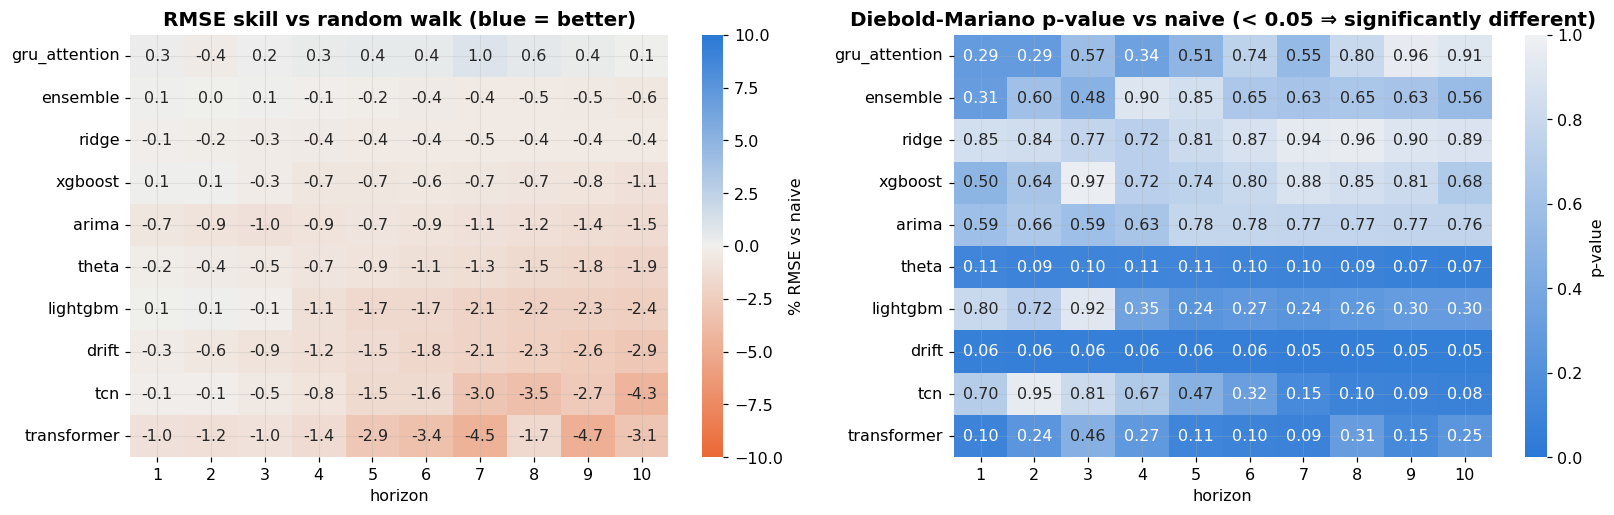

model-horizon pairs significantly different from the random walk at 5%: 1 of 100  (≈ 5 expected by chance)


In [18]:
piv = M.pivot(index="model", columns="horizon", values="Skill_vs_naive_%").drop(index="naive")
piv = piv.loc[piv.mean(axis=1).sort_values(ascending=False).index]
pdm = M.pivot(index="model", columns="horizon", values="DM_p").drop(index="naive").loc[piv.index]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
sns.heatmap(piv, annot=True, fmt=".1f", cmap=DIVERGING, center=0, vmin=-10, vmax=10, ax=ax[0], cbar_kws={"label": "% RMSE vs naive"})
ax[0].set_title("RMSE skill vs random walk (blue = better)"); ax[0].set_ylabel("")
sns.heatmap(pdm, annot=True, fmt=".2f", cmap=sns.light_palette(BLUE, reverse=True, as_cmap=True), vmin=0, vmax=1, ax=ax[1], cbar_kws={"label": "p-value"})
ax[1].set_title("Diebold-Mariano p-value vs naive (< 0.05 ⇒ significantly different)"); ax[1].set_ylabel("")
plt.tight_layout(); shw("12_skill_heatmaps")
sig = (M[(M.model != "naive")].DM_p < 0.05).sum()
print(f"model-horizon pairs significantly different from the random walk at 5%: {sig} of {(M.model != 'naive').sum()}  (≈ {0.05 * (M.model != 'naive').sum():.0f} expected by chance)")

### 5.2 Price accuracy in dollars *and* percent — and the honest comparison with the random walk

In [19]:
rows = []
for h in (1, 3, 5, 7, 10):
    for m in ("naive", "ensemble"):
        d = M[(M.model == m) & (M.horizon == h)].iloc[0]
        p = oof.pred[:, h - 1] if m == "ensemble" else bt.preds[m][:, h - 1]
        ok = np.isfinite(bt.actual[:, h - 1])
        true_p, hat_p = (bt.close * np.exp(bt.actual[:, h - 1]))[ok], (bt.close * np.exp(p))[ok]
        rows.append({"horizon": h, "model": m, "MAE $": d.MAE, "RMSE $": d.RMSE, "MAPE %": d["MAPE_%"],
                     "R² (price level)": r2_score(true_p, hat_p), "within ±5% of actual (%)": (np.abs(hat_p / true_p - 1) < .05).mean() * 100})
acc = pd.DataFrame(rows)
display(acc.pivot(index="horizon", columns="model").swaplevel(axis=1).sort_index(axis=1).style.format("{:.3f}"))
print("Reading: price-level R² and MAPE are almost identical for the ensemble and the naive forecast — the 'accuracy' is real but it is *inherited from the last known price*, not extra skill.")

Reading: price-level R² and MAPE are almost identical for the ensemble and the naive forecast — the 'accuracy' is real but it is *inherited from the last known price*, not extra skill.


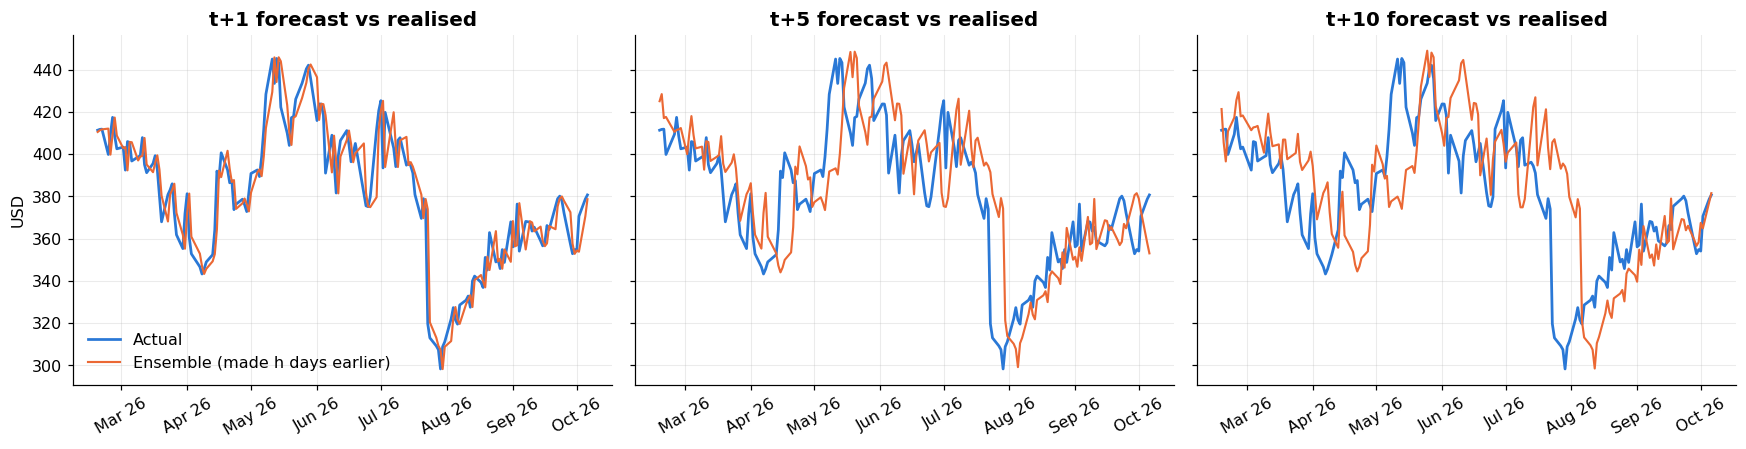

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for a, h in zip(ax, (1, 5, 10)):
    pf = pd.DataFrame({"actual": bt.close * np.exp(bt.actual[:, h - 1]), "ens": bt.close * np.exp(oof.pred[:, h - 1])}, index=bt.dates).dropna()
    pf.index = pf.index + pd.tseries.offsets.BDay(h)       # plot at the target date
    a.plot(pf.index[-160:], pf.actual[-160:], color=BLUE, lw=1.8, label="Actual")
    a.plot(pf.index[-160:], pf.ens[-160:], color=ORANGE, lw=1.4, label="Ensemble (made h days earlier)")
    a.set_title(f"t+{h} forecast vs realised"); a.xaxis.set_major_formatter(mdates.DateFormatter("%b %y")); a.tick_params(axis="x", rotation=30)
ax[0].set_ylabel("USD"); ax[0].legend(); plt.tight_layout(); shw("13_forecast_vs_realised")

### 5.3 Is any edge *stable*? Cumulative error advantage over the random walk

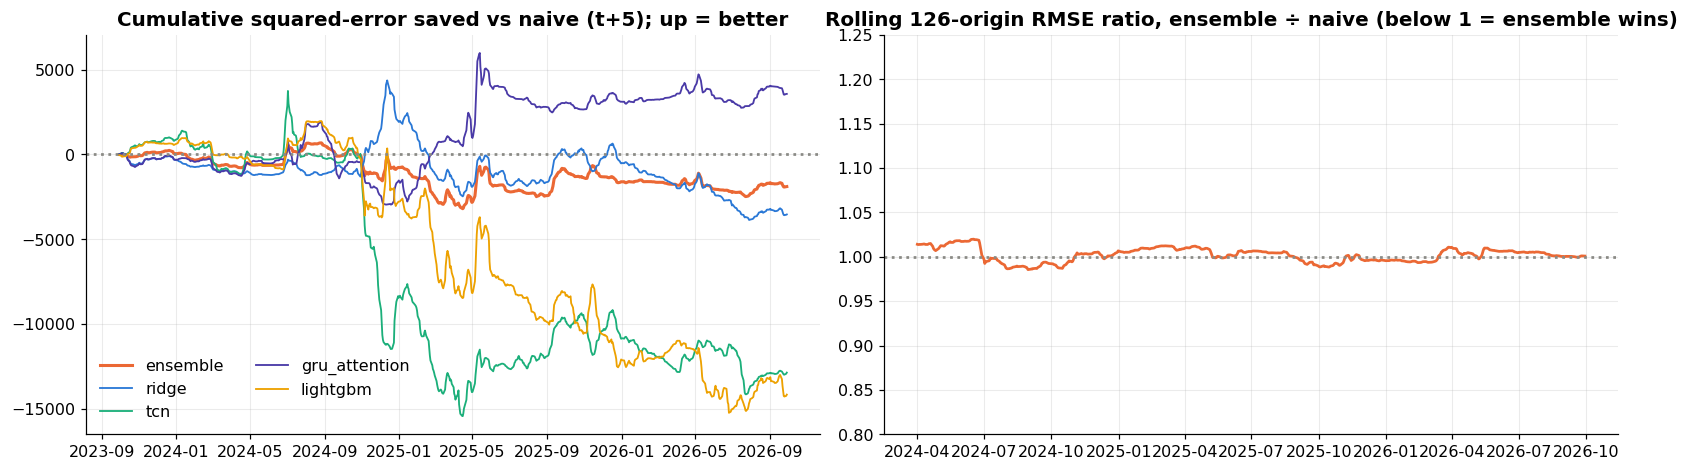

In [21]:
h = 5; j = h - 1
ok = np.isfinite(bt.actual[:, j])
price_true = bt.close * np.exp(bt.actual[:, j])
def sq(p): return (bt.close * np.exp(p) - price_true) ** 2
se_naive = sq(bt.preds["naive"][:, j])
top = [m for m in ("ensemble", "ridge", "tcn", "gru_attention", "lightgbm") if m in bt.preds or m == "ensemble"]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.4))
for m, c in zip(top, (ORANGE, BLUE, AQUA, VIOLET, PALETTE["yellow"])):
    p = oof.pred[:, j] if m == "ensemble" else bt.preds[m][:, j]
    ax[0].plot(bt.dates[ok], np.cumsum((se_naive - sq(p))[ok]), label=m, color=c, lw=2 if m == "ensemble" else 1.2)
ax[0].axhline(0, color=GREY, ls=":"); ax[0].set_title(f"Cumulative squared-error saved vs naive (t+{h}); up = better"); ax[0].legend(ncol=2)
w = 126
ratio = (pd.Series((sq(oof.pred[:, j]))[ok], bt.dates[ok]).rolling(w).mean() / pd.Series(se_naive[ok], bt.dates[ok]).rolling(w).mean()) ** .5
ax[1].plot(ratio.index, ratio, color=ORANGE); ax[1].axhline(1, color=GREY, ls=":")
ax[1].set_title(f"Rolling {w}-origin RMSE ratio, ensemble ÷ naive (below 1 = ensemble wins)"); ax[1].set_ylim(.8, 1.25)
plt.tight_layout(); shw("14_cumulative_error_vs_naive")

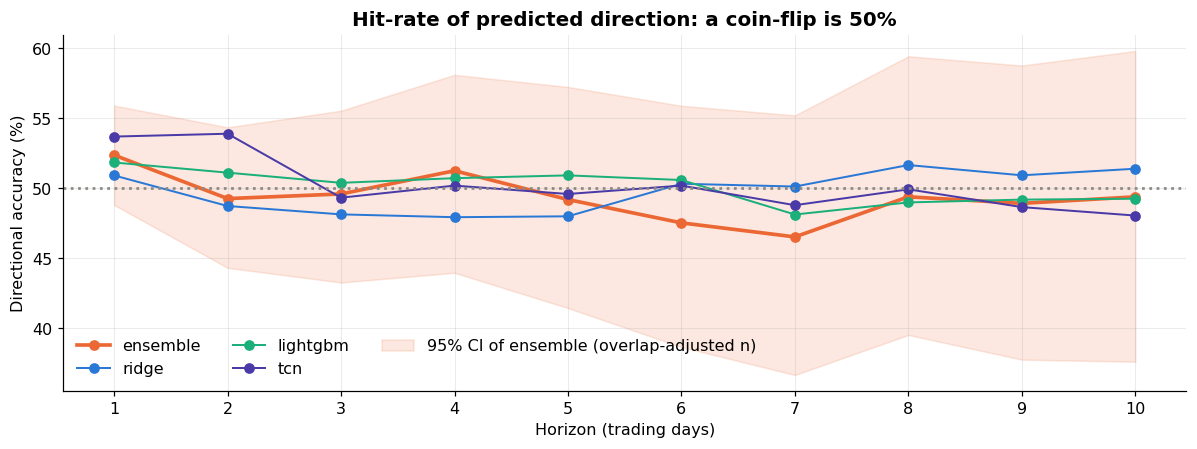

In [22]:
from statsmodels.stats.proportion import proportion_confint
fig, ax = plt.subplots(figsize=(11, 4.2))
for m, c in (("ensemble", ORANGE), ("ridge", BLUE), ("lightgbm", AQUA), ("tcn", VIOLET)):
    d = M[M.model == m].sort_values("horizon")
    ax.plot(d.horizon, d["DirAcc_%"], marker="o", color=c, label=m, lw=2.4 if m == "ensemble" else 1.3)
e = M[M.model == "ensemble"].sort_values("horizon")
lo, hi = zip(*[proportion_confint(int(a / 100 * (n / h)), int(n / h), method="wilson") for a, n, h in zip(e["DirAcc_%"], e.n, e.horizon)])
ax.fill_between(e.horizon, np.array(lo) * 100, np.array(hi) * 100, color=ORANGE, alpha=.15, label="95% CI of ensemble (overlap-adjusted n)")
ax.axhline(50, color=GREY, ls=":"); ax.set_xlabel("Horizon (trading days)"); ax.set_ylabel("Directional accuracy (%)"); ax.set_xticks(range(1, H + 1))
ax.set_title("Hit-rate of predicted direction: a coin-flip is 50%"); ax.legend(ncol=3); plt.tight_layout(); shw("15_directional_accuracy")

## 6 · Online forecast combination (ensemble)

For each origin and horizon, each model is weighted by the inverse of its **trailing squared error, using only outcomes that had already been realised** at that origin (`pos_j + h ≤ pos_i`), sharpened (power 2) and shrunk 15 % toward equal weights. Evaluation weights therefore equal deployable weights — no look-ahead. A unit test destroys all unrealised outcomes and verifies the weights do not change.

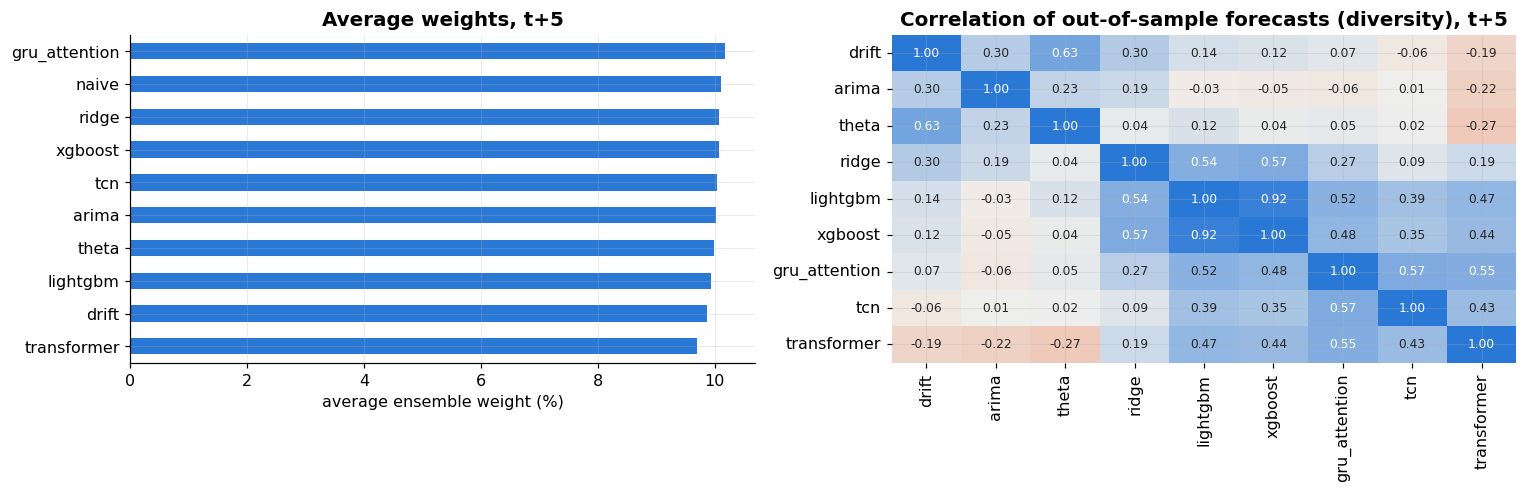

In [23]:
plots.weights_heatmap(bt, oof, 5).show()
avg_w = pd.DataFrame(oof.weights[:, 4, :], columns=oof.names, index=bt.dates)
corr_p = pd.DataFrame({m: bt.preds[m][:, 4] for m in bt.preds if m not in ("naive",)}).corr()
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
avg_w.mean().sort_values().mul(100).plot.barh(ax=ax[0], color=BLUE); ax[0].set_xlabel("average ensemble weight (%)"); ax[0].set_title("Average weights, t+5")
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap=DIVERGING, center=0, vmin=-1, vmax=1, ax=ax[1], cbar=False, annot_kws={"size": 8})
ax[1].set_title("Correlation of out-of-sample forecasts (diversity), t+5")
plt.tight_layout(); shw("16_ensemble_weights_diversity")

## 7 · Calibrated uncertainty: volatility-normalised, rolling conformal intervals

A point forecast for a stock is nearly worthless without a range. Residuals are standardised by `EWMA volatility × √h`, and the **empirical conformal quantiles** of those standardised residuals (rolling 400 realised origins, finite-sample corrected, asymmetric lower/upper) give 80 % and 95 % intervals that **widen automatically in turbulent regimes**. Calibration uses only residuals realised before each origin.

In [24]:
plots.calibration_chart(pipe.coverage).show()
cov = pipe.coverage.pivot(index="horizon", columns="level", values="empirical_coverage")
cov.columns = [f"{int(c * 100)}% nominal" for c in cov.columns]
display((cov * 100).round(1).T.style.format("{:.1f}").set_caption("Empirical coverage (%) of out-of-sample outcomes"))
plots.backtest_chart(bt, oof, 5, last_n=300).show()

horizon,1,2,3,4,5,6,7,8,9,10
80% nominal,81.0,81.5,81.7,82.6,82.3,84.0,83.3,82.6,83.6,84.9
95% nominal,96.0,96.6,96.0,96.0,96.3,96.4,96.7,96.0,95.2,95.3


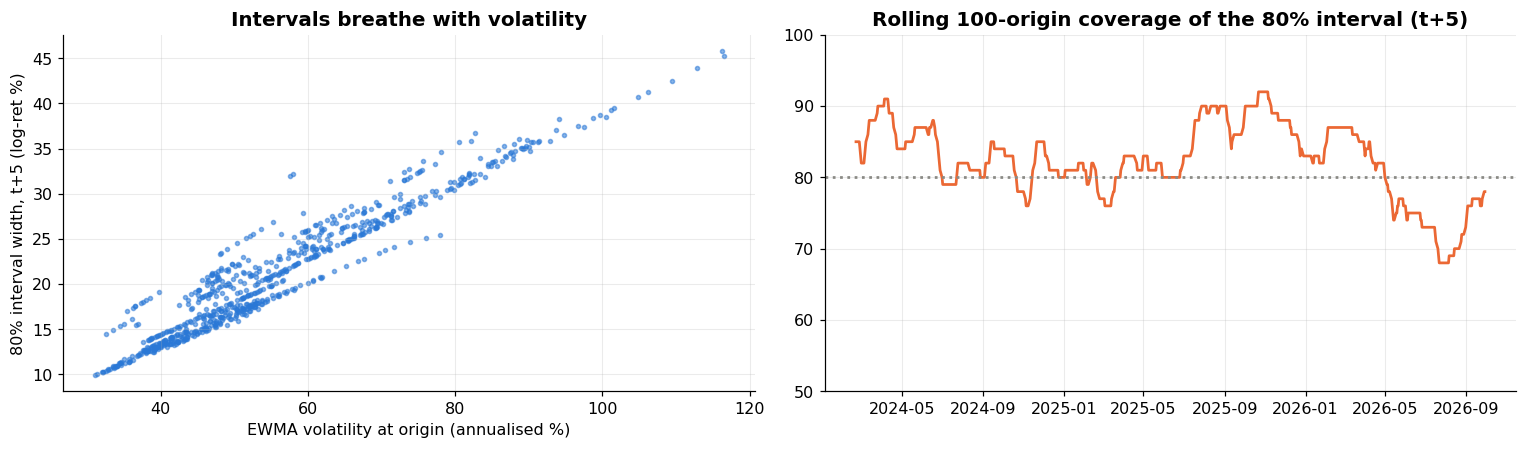

In [25]:
# Benchmark: naive Gaussian intervals  forecast ± z·σ·√h  (same volatility scale, no conformal calibration)
from scipy import stats
from tesla_forecast.evaluation.metrics import coverage_table
def interval_score(y, lo, hi, a):
    return (hi - lo) + 2 / a * np.maximum(lo - y, 0) + 2 / a * np.maximum(y - hi, 0)

rows = []
for lv in pipe.cfg.intervals.levels:
    z = stats.norm.ppf(0.5 + lv / 2)
    g = {lv: (oof.pred - z * oof.scale, oof.pred + z * oof.scale)}
    for name, (lo, hi) in (("conformal", oof.bounds[lv]), ("Gaussian", g[lv])):
        ok = np.isfinite(bt.actual)
        c = ((bt.actual >= lo) & (bt.actual <= hi))[ok].mean()
        rows.append({"level": f"{int(lv * 100)}%", "method": name, "coverage %": c * 100,
                     "avg width (log-ret %)": (hi - lo)[ok].mean() * 100,
                     "Winkler score ↓": np.nanmean(interval_score(bt.actual, lo, hi, 1 - lv)[ok]) * 100})
cmp_ = pd.DataFrame(rows)
display(cmp_.set_index(["level", "method"]).style.format("{:.2f}"))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
w = (oof.bounds[0.8][1] - oof.bounds[0.8][0])[:, 4] * 100
ax[0].scatter(bt.vol * np.sqrt(252) * 100, w, s=7, color=BLUE, alpha=.55); ax[0].set_xlabel("EWMA volatility at origin (annualised %)")
ax[0].set_ylabel("80% interval width, t+5 (log-ret %)"); ax[0].set_title("Intervals breathe with volatility")
ok5 = np.isfinite(bt.actual[:, 4])
hit = pd.Series(((bt.actual[:, 4] >= oof.bounds[0.8][0][:, 4]) & (bt.actual[:, 4] <= oof.bounds[0.8][1][:, 4]))[ok5], bt.dates[ok5]).rolling(100).mean() * 100
ax[1].plot(hit.index, hit, color=ORANGE); ax[1].axhline(80, color=GREY, ls=":"); ax[1].set_ylim(50, 100)
ax[1].set_title("Rolling 100-origin coverage of the 80% interval (t+5)"); plt.tight_layout(); shw("17_interval_width_rolling_coverage")

## 8 · Residual diagnostics (ensemble, t+5)

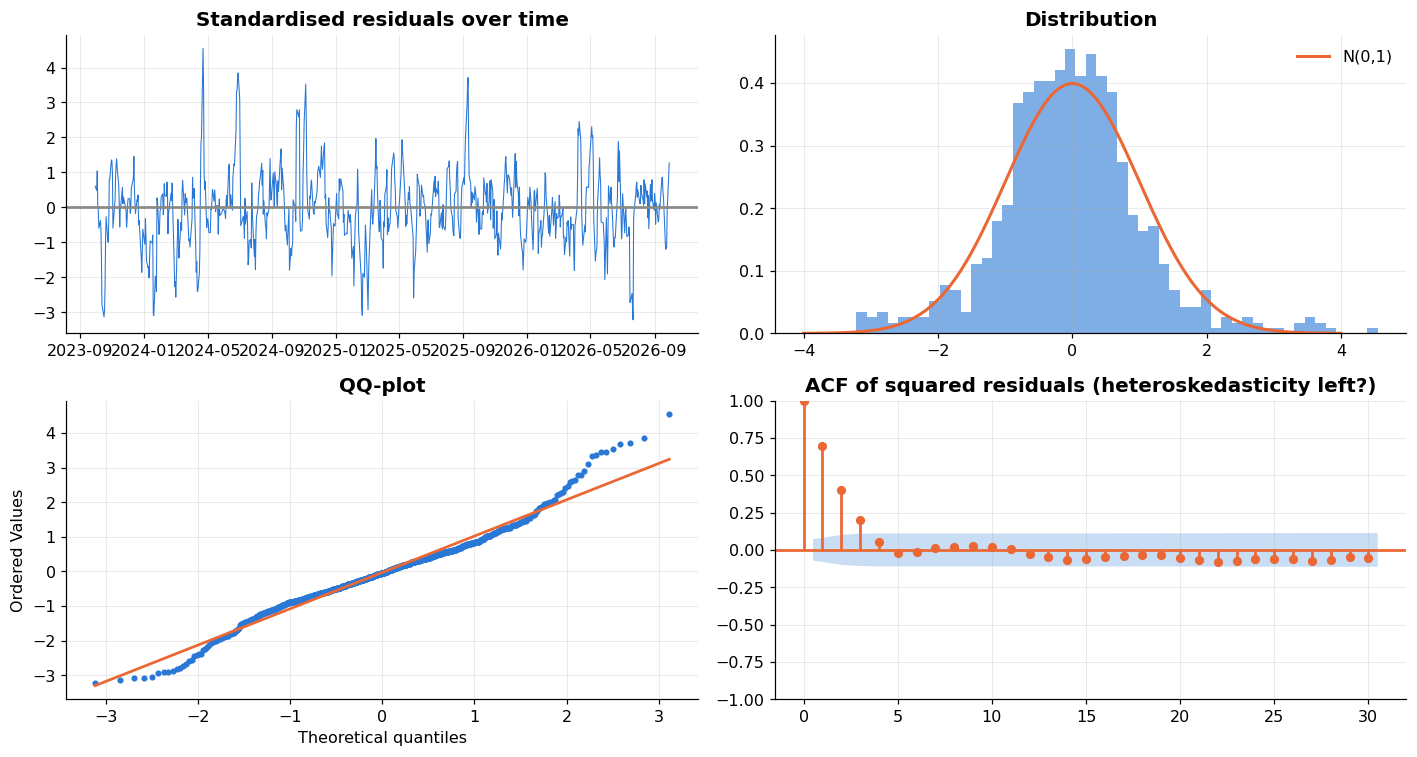

,residuals,squared residuals
lag,,
10,0.000,0.000
20,0.000,0.000


mean standardised residual -0.029 (bias), std 1.062, skew +0.28, excess kurtosis +1.74


In [26]:
from statsmodels.graphics.tsaplots import plot_acf
res5 = pd.Series(oof.scores[:, 4], bt.dates).dropna()           # standardised residuals
fig, ax = plt.subplots(2, 2, figsize=(13, 7))
ax[0, 0].plot(res5.index, res5, color=BLUE, lw=.7); ax[0, 0].axhline(0, color=GREY); ax[0, 0].set_title("Standardised residuals over time")
ax[0, 1].hist(res5, bins=50, density=True, color=BLUE, alpha=.6); xs = np.linspace(-4, 4, 300)
ax[0, 1].plot(xs, stats.norm.pdf(xs), color=ORANGE, lw=2, label="N(0,1)"); ax[0, 1].legend(); ax[0, 1].set_title("Distribution")
stats.probplot(res5, dist="norm", plot=ax[1, 0]); ax[1, 0].get_lines()[0].set(color=BLUE, markersize=3); ax[1, 0].get_lines()[1].set(color=ORANGE); ax[1, 0].set_title("QQ-plot")
plot_acf(res5 ** 2, lags=30, ax=ax[1, 1], color=ORANGE, vlines_kwargs={"colors": ORANGE}); ax[1, 1].set_title("ACF of squared residuals (heteroskedasticity left?)")
plt.tight_layout(); shw("18_residual_diagnostics")
lb = acorr_ljungbox(res5, lags=[10, 20], return_df=True)["lb_pvalue"]; lb2 = acorr_ljungbox(res5 ** 2, lags=[10, 20], return_df=True)["lb_pvalue"]
display(pd.DataFrame({"residuals": lb, "squared residuals": lb2}).rename_axis("lag").style.format("{:.3f}")
        .set_caption("Ljung-Box p-values — note: h-step residuals overlap, so low p-values for residuals are expected"))
print(f"mean standardised residual {res5.mean():+.3f} (bias), std {res5.std():.3f}, skew {stats.skew(res5):+.2f}, excess kurtosis {stats.kurtosis(res5):+.2f}")

## 9 · Final models, interpretability and training curves

`pipe.fit()` trains every model on **all** available history (these are the models that produce the live forecast).

In [27]:
pipe.fit()
print({k: type(v).__name__ for k, v in pipe.models.items()})
print("trained through:", pipe.trained_through.date())

02:36:46 | INFO    | tesla_forecast.forecasting.pipeline | fitted naive          0.0s


02:36:46 | INFO    | tesla_forecast.forecasting.pipeline | fitted drift          0.0s


02:36:47 | INFO    | tesla_forecast.forecasting.pipeline | fitted arima          1.3s


02:36:47 | INFO    | tesla_forecast.forecasting.pipeline | fitted theta          0.0s


02:36:48 | INFO    | tesla_forecast.forecasting.pipeline | fitted ridge          0.1s


...

02:36:48 | INFO    | tesla_forecast.forecasting.pipeline | fitted xgboost        0.2s


02:36:49 | INFO    | tesla_forecast.forecasting.pipeline | fitted gru_attention  0.8s


02:36:50 | INFO    | tesla_forecast.forecasting.pipeline | fitted tcn            1.4s


02:36:52 | INFO    | tesla_forecast.forecasting.pipeline | fitted transformer    2.0s


{'naive': 'NaiveForecaster', 'drift': 'DriftForecaster', 'arima': 'ARIMAForecaster', 'theta': 'ThetaForecaster', 'ridge': 'RidgeForecaster', 'lightgbm': 'GBMForecaster', 'xgboost': 'GBMForecaster', 'gru_attention': 'DeepForecaster', 'tcn': 'DeepForecaster', 'transformer': 'DeepForecaster'}
trained through: 2026-10-06


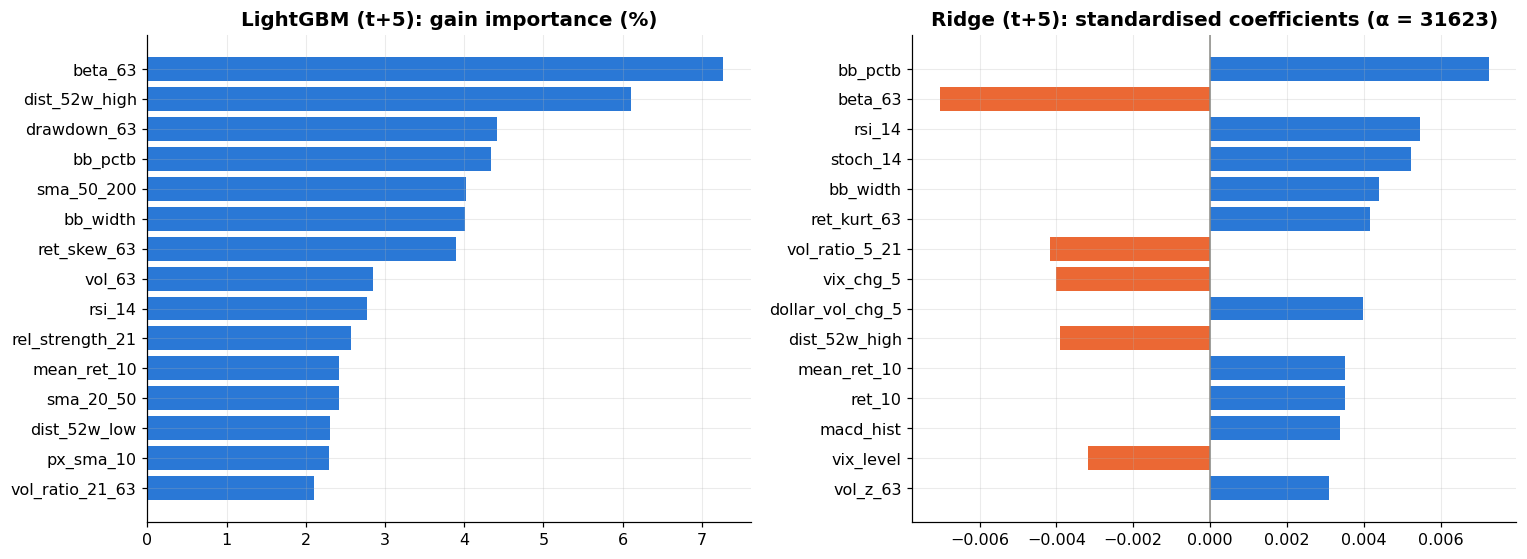

In [28]:
lgbm = pipe.models["lightgbm"]; j5 = lgbm.anchors_.index(5)
booster = lgbm.models_[j5]
imp = pd.Series(booster.booster_.feature_importance("gain"), index=fcols); imp = (imp / imp.sum() * 100).sort_values().tail(15)
ridge = pipe.models["ridge"]._pipe; coef = pd.Series(ridge.named_steps["ridge"].coef_[4], index=fcols)
cs = coef.reindex(coef.abs().sort_values().tail(15).index)
fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))
ax[0].barh(imp.index, imp.values, color=BLUE); ax[0].set_title("LightGBM (t+5): gain importance (%)")
ax[1].barh(cs.index, cs.values, color=[BLUE if v > 0 else ORANGE for v in cs]); ax[1].axvline(0, color=GREY, lw=1)
ax[1].set_title(f"Ridge (t+5): standardised coefficients (α = {pipe.models['ridge'].alpha_:.0f})")
plt.tight_layout(); shw("19_feature_importance")

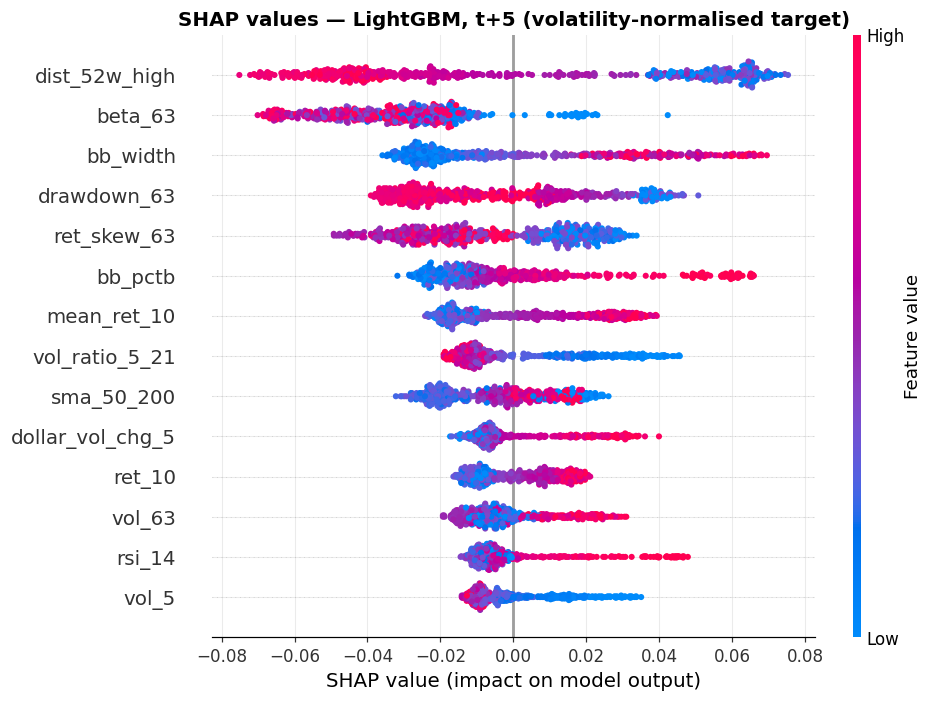

In [29]:
import shap
Xs = frame[fcols].iloc[-600:]
target_ret = booster.predict(Xs)
try:
    sv = shap.TreeExplainer(booster).shap_values(Xs)
    plt.figure(figsize=(9, 6.5)); shap.summary_plot(sv, Xs, max_display=14, show=False, plot_size=None)
    plt.title("SHAP values — LightGBM, t+5 (volatility-normalised target)"); plt.tight_layout(); shw("20_shap_summary")
except Exception as exc:                                    # SHAP is optional; never block the notebook
    print("SHAP summary skipped:", type(exc).__name__, exc)

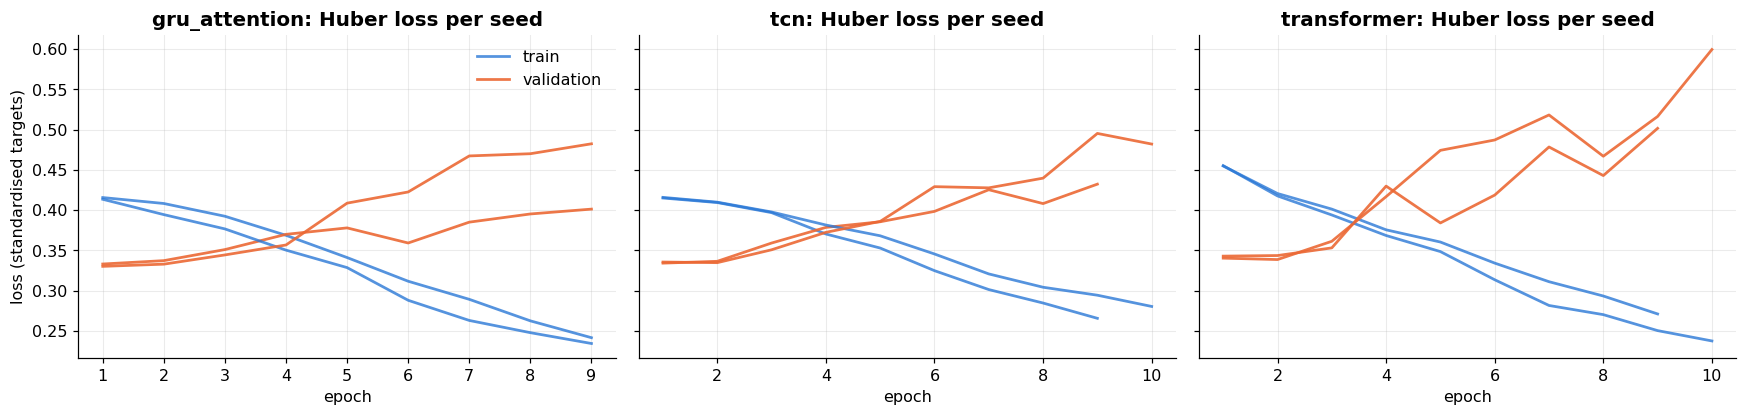

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.9), sharey=True)
for a, name in zip(ax, ("gru_attention", "tcn", "transformer")):
    for k, hist in enumerate(pipe.models[name].history_):
        h_ = pd.DataFrame(hist)
        a.plot(h_.epoch, h_.train_loss, color=BLUE, alpha=.8, label="train" if k == 0 else None)
        a.plot(h_.epoch, h_.val_loss, color=ORANGE, alpha=.9, label="validation" if k == 0 else None)
    a.set_title(f"{name}: Huber loss per seed"); a.set_xlabel("epoch")
ax[0].legend(); ax[0].set_ylabel("loss (standardised targets)"); plt.tight_layout(); shw("21_training_curves")

## 10 · Forecast: the next two trading weeks

Point path = online-weighted ensemble; shaded bands = calibrated 80 % / 95 % conformal intervals; `P(up)` is the model-implied probability the price is above today's close at each horizon (from the empirical standardised-residual distribution, not a Gaussian assumption).

In [31]:
res = pipe.forecast()
tbl = res.to_frame()
print(f"As of {res.as_of.date()} · last close ${res.last_close:,.2f} · data source: {res.data_source}")
display(tbl.style.format({"forecast": "${:,.2f}", "change_%": "{:+.2f}%", "prob_up_%": "{:.0f}%",
                          **{c: "${:,.2f}" for c in tbl.columns if c.startswith(("lower", "upper"))}})
        .background_gradient(subset=["prob_up_%"], cmap=DIVERGING, vmin=30, vmax=70))
plots.forecast_chart(close, res, history=90).show()

As of 2026-10-06 · last close $380.68 · data source: cache


,forecast,change_%,prob_up_%,lower_80,upper_80,lower_95,upper_95
date,,,,,,,
2026-10-07 00:00:00,$380.63,-0.01%,51%,$368.34,$392.91,$360.11,$400.74
2026-10-08 00:00:00,$380.31,-0.10%,48%,$363.89,$397.74,$350.00,$410.83
2026-10-09 00:00:00,$380.39,-0.08%,48%,$362.35,$400.94,$344.15,$422.15
2026-10-12 00:00:00,$380.29,-0.10%,50%,$358.21,$404.06,$335.40,$425.63
2026-10-13 00:00:00,$380.64,-0.01%,49%,$357.97,$407.38,$335.72,$428.11
2026-10-14 00:00:00,$380.84,+0.04%,50%,$356.67,$407.59,$333.47,$433.92
2026-10-15 00:00:00,$381.46,+0.20%,52%,$354.66,$408.72,$328.88,$442.54
2026-10-16 00:00:00,$381.55,+0.23%,53%,$352.13,$410.18,$328.96,$454.56
2026-10-19 00:00:00,$382.18,+0.40%,53%,$350.71,$410.86,$326.47,$455.32


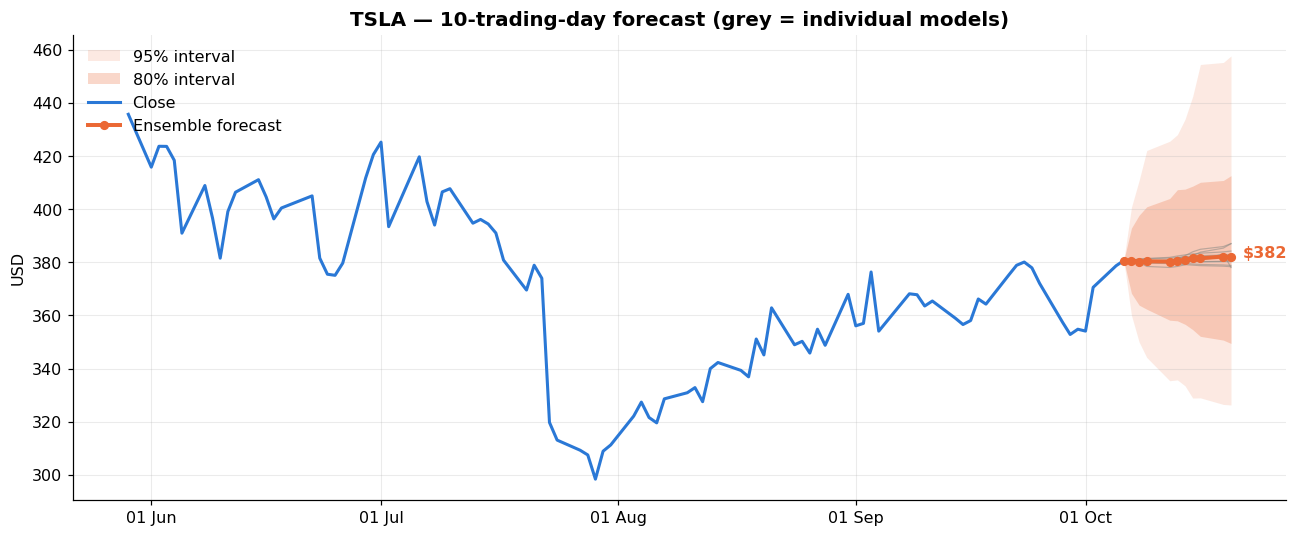

,2026-10-07 00:00:00,2026-10-08 00:00:00,2026-10-09 00:00:00,2026-10-12 00:00:00,2026-10-13 00:00:00,2026-10-14 00:00:00,2026-10-15 00:00:00,2026-10-16 00:00:00,2026-10-19 00:00:00,2026-10-20 00:00:00
naive,$380.68,$380.68,$380.68,$380.68,$380.68,$380.68,$380.68,$380.68,$380.68,$380.68
drift,$380.50,$380.31,$380.13,$379.95,$379.76,$379.58,$379.40,$379.22,$379.03,$378.85
arima,$380.91,$381.14,$381.37,$381.60,$381.83,$382.06,$382.29,$382.52,$382.76,$382.99
theta,$380.13,$379.93,$379.74,$379.54,$379.35,$379.15,$378.96,$378.76,$378.57,$378.37
ridge,$380.95,$381.18,$381.47,$381.89,$382.39,$382.82,$383.17,$383.46,$383.94,$384.26
lightgbm,$381.15,$379.54,$380.68,$380.93,$381.23,$382.50,$383.97,$384.93,$385.95,$387.06
xgboost,$380.74,$380.04,$379.96,$380.02,$380.13,$381.20,$382.46,$383.84,$385.37,$387.04
gru_attention,$380.81,$379.82,$380.36,$380.36,$380.55,$380.35,$381.24,$380.88,$383.21,$378.03
tcn,$380.92,$380.45,$381.02,$379.85,$381.99,$381.00,$381.40,$380.20,$380.38,$381.14
transformer,$379.49,$379.99,$378.47,$378.08,$378.46,$379.11,$381.05,$381.13,$381.86,$381.03


disagreement across models at t+10: std = $3.32  vs 80% interval half-width ≈ $31.62


In [32]:
hist = close.iloc[-90:]; x_f = [hist.index[-1], *res.dates]
fig, ax = plt.subplots(figsize=(12, 5))
for lv, a in sorted(res.bounds.items(), reverse=True):
    lo, hi = res.bounds[lv]
    ax.fill_between(x_f, [res.last_close, *lo], [res.last_close, *hi], color=ORANGE, alpha=.14 if lv > .9 else .26, label=f"{int(lv * 100)}% interval", lw=0)
for name, p in res.model_prices.items():
    ax.plot(x_f, [res.last_close, *p], color=GREY, lw=.8, alpha=.55)
ax.plot(hist.index, hist, color=BLUE, lw=2, label="Close")
ax.plot(x_f, [res.last_close, *res.price], color=ORANGE, lw=2.6, marker="o", ms=5, label="Ensemble forecast")
ax.annotate(f"${res.price[-1]:,.0f}", (res.dates[-1], res.price[-1]), textcoords="offset points", xytext=(8, 0), color=ORANGE, fontweight="bold")
ax.set_title(f"TSLA — {res.horizon}-trading-day forecast (grey = individual models)"); ax.set_ylabel("USD"); ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b")); plt.tight_layout(); shw("22_forecast")

by_model = pd.DataFrame(res.model_prices, index=res.dates); by_model["ensemble"] = res.price
display(by_model.round(2).T.style.format("${:,.2f}").background_gradient(axis=0, cmap=DIVERGING, vmin=res.last_close * .93, vmax=res.last_close * 1.07)
        .set_caption("Every model's price path (columns = dates)"))
print(f"disagreement across models at t+{H}: std = ${by_model.drop(columns='ensemble').iloc[-1].std():.2f}  vs 80% interval half-width ≈ ${(res.bounds[.8][1][-1] - res.bounds[.8][0][-1]) / 2:.2f}")

## 11 · Risk view: Monte-Carlo simulation (filtered historical simulation)

Complementary to the interval forecasts: 5 000 price paths from bootstrapped, volatility-standardised historical shocks, with EWMA volatility feeding back along each path (volatility clustering). Drift = the ensemble forecast.

In [33]:
sim = pipe.simulate(res)
plots.simulation_chart(sim).show()
risk = pd.Series(sim.risk_summary(), name="value")
c80 = res.bounds[.8]
cons = pd.DataFrame({"conformal 80% (t+H)": [c80[0][-1], c80[1][-1]],
                     "simulation 10-90 pct (t+H)": [np.percentile(sim.terminal, 10), np.percentile(sim.terminal, 90)]}, index=["lower", "upper"])
display(risk.to_frame().style.format("{:.2f}")); display(cons.style.format("${:,.2f}").set_caption("Two independent uncertainty methods should roughly agree"))

,value
prob_up_%,53.06
expected_return_%,0.69
median_return_%,0.63
VaR_95_%,-11.36
CVaR_95_%,-15.23
prob_gain_>10%,10.20
prob_loss_>10%,6.76
expected_max_drawdown_%,-6.10
worst_5%_max_drawdown_%,-14.06


,conformal 80% (t+H),simulation 10-90 pct (t+H)
lower,$349.44,$348.81
upper,$412.68,$418.99


## 12 · Volatility outlook (GJR-GARCH-t vs EWMA)

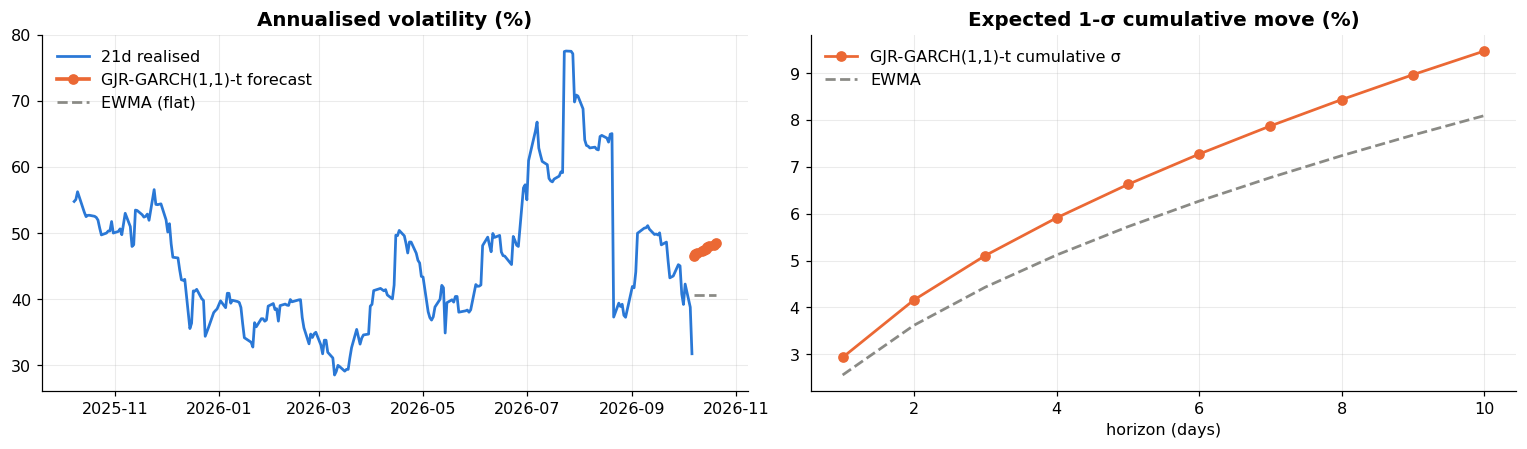

Current 21-day volatility sits at the 11th percentile of its history; GARCH expects a 1-σ move of ±9.5% by day 10.


In [34]:
from tesla_forecast.models.volatility import garch_variance_path, ewma_variance_path
g_var, g_name = garch_variance_path(ret, H); e_var = ewma_variance_path(ret, H)
pct = (ret.rolling(21).std().dropna() <= ret.iloc[-21:].std()).mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
hist_v = ret.rolling(21).std().iloc[-250:] * np.sqrt(252) * 100
ax[0].plot(hist_v.index, hist_v, color=BLUE, label="21d realised")
fut = pd.DatetimeIndex(res.dates)
ax[0].plot(fut, np.sqrt(g_var) * np.sqrt(252) * 100, color=ORANGE, lw=2.4, marker="o", label=f"{g_name} forecast")
ax[0].plot(fut, np.sqrt(e_var) * np.sqrt(252) * 100, color=GREY, ls="--", label="EWMA (flat)"); ax[0].legend(); ax[0].set_title("Annualised volatility (%)")
cum_sd = np.sqrt(np.cumsum(g_var)) * 100
ax[1].plot(range(1, H + 1), cum_sd, color=ORANGE, marker="o", label=f"{g_name} cumulative σ")
ax[1].plot(range(1, H + 1), np.sqrt(np.cumsum(e_var)) * 100, color=GREY, ls="--", label="EWMA"); ax[1].legend()
ax[1].set_title("Expected 1-σ cumulative move (%)"); ax[1].set_xlabel("horizon (days)"); plt.tight_layout(); shw("23_volatility_outlook")
print(f"Current 21-day volatility sits at the {pct:.0f}th percentile of its history; GARCH expects a 1-σ move of ±{cum_sd[-1]:.1f}% by day {H}.")

## 13 · News sentiment & insights

Headlines come from Google News RSS (Yahoo as backup) and are scored with a transparent finance-lexicon (negation/intensifier aware). **This is context for the reader, not a model input** — there is no point-in-time news archive in the training data, so claiming it improves forecasts would be unverifiable. If `LLM_PROVIDER` is configured (see `.env.example`), an LLM rewrites the computed insights; otherwise deterministic rules do.

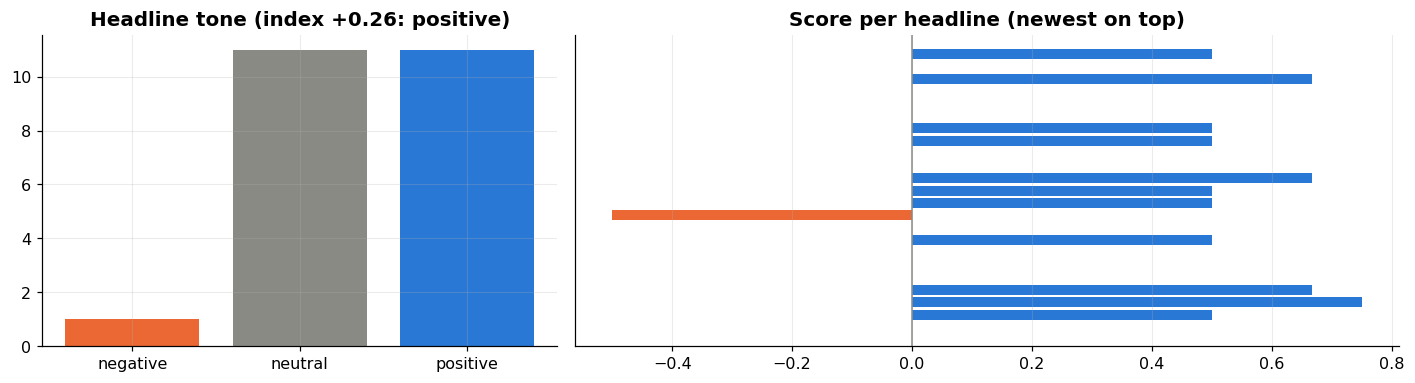

,published,source,title,score,label
0,2026-10-06 15:53:05,TipRanks,“Gray Kittens” Keeping Robotaxis in at Night; Tesla Stock (NASDAQ:TSLA) Gains Despite Early Nights for Robotaxis,+0.50,positive
1,2026-10-06 15:27:17,Benzinga,"SpaceX, Tesla Trade Like One Elon Musk Stock",+0.00,neutral
2,2026-10-06 05:42:16,Yahoo Finance,TSLA Stock Rises Overnight: Analyst Says SpaceX Merger Buzz Could ‘Dominate’ Near-Term Narrative — Gary Black Sees More Gains Ahead,+0.67,positive
3,2026-10-05 23:11:00,The Motley Fool,Tesla Reports Quarterly Production and Delivery Figures. Here's What It Means for Investors,+0.00,neutral
4,2026-10-05 20:45:03,Yahoo Finance,Tesla (TSLA) Laps the Stock Market: Here's Why,+0.00,neutral
5,2026-10-05 19:01:25,Benzinga,"Amazon, Alphabet and Tesla: Robinhood Traders Sell - Tesla (NASDAQ:TSLA), Amazon.com (NASDAQ:AMZN), Alpha",+0.00,neutral
6,2026-10-05 17:49:21,TradingView,Tesla Stock Rises After Musk Confirms TSMC Talks,+0.50,positive
7,2026-10-05 16:15:04,Benzinga,Tesla Stock Trends Higher: What's Happening?,+0.50,positive
8,2026-10-05 13:00:00,24/7 Wall St.,"If You Invest $10,000 in Tesla Today, Here’s What It Could Be Worth by 2030",+0.00,neutral
9,2026-10-05 08:56:27,Simply Wall Street,3 Fast Growing Stocks To Own In October 2026,+0.00,neutral


### Insights  
*source: rules*

**Trend Analysis** — TSLA is in a mixed trend: +8.7% vs the 50-day and -2.9% vs the 200-day average. Returns: +7.9% over 5 days and +7.5% over 21 days; price is 22.3% below its 52-week high.

**Technical Indicators** — RSI(14) is 60 (neutral); MACD histogram is positive; Bollinger %B is 0.87. 21-day realised volatility is 32% annualised (ATR 3.2% of price); volume is 0.7x its 21-day average.

**Market Sentiment** — Recency-weighted headline tone is positive (index +0.26) across 23 headlines: 11 positive, 1 negative, 11 neutral.

**Economic Factors** — Not derived from data here. Typical drivers for TSLA: rates and growth expectations, EV demand and pricing, delivery numbers, regulation/tariffs, and broader tech risk appetite.

**Prediction** — The ensemble expects $381.95 in 10 trading days (+0.3%), 80% interval $349-$413, with a model-implied 53% chance of finishing above today's close. Treat the direction as low-confidence: the central estimate is small relative to the interval width.

**Risks** — Statistical forecasts of stocks are weak; large gap moves on news can fall outside any interval.

In [35]:
from tesla_forecast.sentiment import fetch_headlines, sentiment_index, generate_insights, technical_snapshot
news = fetch_headlines("TSLA", limit=25)
senti = sentiment_index(news)
if not senti:
    print("No headlines available (offline or feed blocked) — sentiment section skipped.")
else:
    sc = senti["scored"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [1, 1.6]})
    cnt = sc.label.value_counts().reindex(["negative", "neutral", "positive"]).fillna(0)
    ax[0].bar(cnt.index, cnt.values, color=[ORANGE, GREY, BLUE]); ax[0].set_title(f"Headline tone (index {senti['index']:+.2f}: {senti['label']})")
    ax[1].barh(range(len(sc))[::-1], sc.score, color=[BLUE if s > 0 else ORANGE if s < 0 else GREY for s in sc.score])
    ax[1].set_yticks([]); ax[1].axvline(0, color=GREY, lw=1); ax[1].set_title("Score per headline (newest on top)")
    plt.tight_layout(); shw("24_news_sentiment")
    display(sc[["published", "source", "title", "score", "label"]].head(12).style.format({"score": "{:+.2f}"}).set_properties(subset=["title"], **{"white-space": "normal"}))

fdict = {"horizon": res.horizon, "price_end": float(res.price[-1]), "change_%": float((res.price[-1] / res.last_close - 1) * 100),
         "lo80": float(res.bounds[.8][0][-1]), "hi80": float(res.bounds[.8][1][-1]), "prob_up_%": float(res.prob_up[-1] * 100)}
insights, source = generate_insights(technical_snapshot(prices), fdict, senti or None, list(news["title"]) if len(news) else [])
display(Markdown(f"### Insights  \n*source: {source}*\n\n" + "\n\n".join(f"**{k.replace('_', ' ').title()}** — {v}" for k, v in insights.items())))

## 14 · Persist artifacts

In [36]:
path = pipe.save()
out = ROOT / cfg.paths.reports_dir; out.mkdir(exist_ok=True)
tbl.to_csv(out / "latest_forecast.csv"); M.to_csv(out / "backtest_metrics.csv", index=False); pipe.coverage.to_csv(out / "interval_coverage.csv", index=False)
from tesla_forecast.viz.report import save_report_figures
extra = save_report_figures(pipe, res, sim, FIG)          # static twins of the interactive Plotly charts
print("pipeline  →", path.relative_to(ROOT), f"({path.stat().st_size / 1e6:.1f} MB)  — loaded by the Streamlit app")
print("reports   →", ", ".join(p.name for p in sorted(out.glob("*.csv"))), f"| {len(list(FIG.glob('*.png')))} figures in reports/figures/")

02:36:56 | INFO    | tesla_forecast.forecasting.pipeline | saved pipeline -> /media/junaid-ul-hassan/NewVolume/Personal-Projects/Tesla_Market_Sentiment_analysis/artifacts/pipeline.joblib


pipeline  → artifacts/pipeline.joblib (3.2 MB)  — loaded by the Streamlit app
reports   → backtest_metrics.csv, interval_coverage.csv, latest_forecast.csv | 31 figures in reports/figures/


## 15 · Conclusions (computed from this run)

In [37]:
best = {h: M[(M.horizon == h) & (M.model != "ensemble")].sort_values("RMSE").iloc[0] for h in (1, 5, H)}
ens = {h: M[(M.horizon == h) & (M.model == "ensemble")].iloc[0] for h in (1, 5, H)}
cov_mean = pipe.coverage.groupby("level").empirical_coverage.mean()
nb_ = M[(M.model != "naive")]
better = nb_[(nb_.DM_p < 0.05) & (nb_["Skill_vs_naive_%"] > 0)]
worse = nb_[(nb_.DM_p < 0.05) & (nb_["Skill_vs_naive_%"] < 0)]
lines = [f"**Significance scan.** Of {len(nb_)} model-horizon pairs, {len(better)} are significantly *better* than the random walk (5% level) and {len(worse)} significantly *worse*; "
         f"≈ {0.05 * len(nb_):.0f} of each would appear by chance alone.",
         f"**Point accuracy.** t+1 / t+5 / t+{H} ensemble MAPE = {ens[1]['MAPE_%']:.2f}% / {ens[5]['MAPE_%']:.2f}% / {ens[H]['MAPE_%']:.2f}% "
         f"(RMSE ${ens[1].RMSE:.1f} / ${ens[5].RMSE:.1f} / ${ens[H].RMSE:.1f}).",
         f"**Versus the random walk.** Ensemble RMSE skill = {ens[1]['Skill_vs_naive_%']:+.2f}% / {ens[5]['Skill_vs_naive_%']:+.2f}% / {ens[H]['Skill_vs_naive_%']:+.2f}% "
         f"(Diebold-Mariano p = {ens[1].DM_p:.2f} / {ens[5].DM_p:.2f} / {ens[H].DM_p:.2f}). Best single model per horizon: "
         + ", ".join(f"{b.model} (t+{h}: {b['Skill_vs_naive_%']:+.2f}%)" for h, b in best.items()) + ".",
         f"**Direction.** Ensemble hit-rate {ens[1]['DirAcc_%']:.1f}% / {ens[5]['DirAcc_%']:.1f}% / {ens[H]['DirAcc_%']:.1f}% (50 % = coin flip).",
         f"**Uncertainty.** Empirical coverage of the nominal " + " and ".join(f"{int(k * 100)}%" for k in cov_mean.index) + " intervals: "
         + " and ".join(f"{v * 100:.1f}%" for v in cov_mean.values) + " — this is where the system is genuinely reliable.",
         f"**Latest call.** From ${res.last_close:,.2f} (as of {res.as_of.date()}) the ensemble expects ${res.price[-1]:,.2f} ({(res.price[-1] / res.last_close - 1) * 100:+.1f}%) by {res.dates[-1].date()}, "
         f"80% range ${res.bounds[.8][0][-1]:,.0f}–${res.bounds[.8][1][-1]:,.0f}, P(up) = {res.prob_up[-1] * 100:.0f}%."]
display(Markdown("\n\n".join(lines)))

**Significance scan.** Of 100 model-horizon pairs, 0 are significantly *better* than the random walk (5% level) and 1 significantly *worse*; ≈ 5 of each would appear by chance alone.

**Point accuracy.** t+1 / t+5 / t+10 ensemble MAPE = 2.63% / 5.91% / 8.58% (RMSE $11.1 / $23.8 / $33.6).

**Versus the random walk.** Ensemble RMSE skill = +0.09% / -0.22% / -0.58% (Diebold-Mariano p = 0.31 / 0.85 / 0.56). Best single model per horizon: gru_attention (t+1: +0.25%), gru_attention (t+5: +0.42%), gru_attention (t+10: +0.13%).

**Direction.** Ensemble hit-rate 52.4% / 49.2% / 49.4% (50 % = coin flip).

**Uncertainty.** Empirical coverage of the nominal 80% and 95% intervals: 82.7% and 96.0% — this is where the system is genuinely reliable.

**Latest call.** From $380.68 (as of 2026-10-06) the ensemble expects $381.95 (+0.3%) by 2026-10-20, 80% range $349–$413, P(up) = 53%.

### How to interpret all this

* **Accuracy that is real:** dollar errors and MAPE are small *because the last close is an excellent anchor*; the interval forecasts and risk numbers are **well calibrated** and adapt to volatility.
* **Edge that is not demonstrated:** the significance scan above counts how many model/horizon pairs beat the random walk at the 5 % level — compare it with the number expected by chance, and look at the cumulative-error plots for stability. Differences of ±1–2 % RMSE are inside the noise. That is the well-documented behaviour of liquid stocks, not a bug — and it is exactly why the notebook reports skill against the benchmark instead of R².
* **Use it for:** scenario ranges, risk sizing, probability statements and monitoring regime change — not for confident point-price calls.
* **Next experiments:** point-in-time news/options-implied features, intraday realised-vol features, quantile-regression nets trained directly on pinball loss, regime-switching ensembles.